# 02a_2D - constrained P-splines dla danych rzeczywistych 2D

## Cel notebooka

Ten notebook dopasowuje **jeden model 2D P-splines z asymetryczną karą monotoniczności** do danych z pliku CSV. W wersji `02a` domyślnym wejściem są dane rzeczywiste:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

W tym pliku nie ma kolumn `true_*`, dlatego notebook **nie wykonuje porównań z wartościami prawdziwymi**. Nadal wykonuje jednak wszystkie obliczenia modelu:

- dopasowanie powierzchni `pred_z`,
- predykcję pochodnych pierwszego rzędu `pred_dz_dx`, `pred_dz_dy`,
- predykcję pochodnych drugiego rzędu `pred_d2z_dx2`, `pred_d2z_dxdy`, `pred_d2z_dy2`,
- diagnostykę monotoniczności względem osi modelowej `x`,
- eksport danych źródłowych oraz predykcji do pliku CSV.

## Obsługiwane typy danych

Notebook zachowuje mechanizm automatycznego rozpoznawania typu danych.

### 1. Dane rzeczywiste / pomiarowe — tryb domyślny

Dla pliku:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

przyjmowane jest mapowanie:

- `x = I`,
- `y = T`,
- `target_z = Uraw`.

Jeżeli w pliku nie ma `std_z`, model używa wag jednostkowych. Jeżeli w pliku nie ma kolumn `true_*`, sekcje benchmarkowe są pomijane bez błędu.

### 2. Dane syntetyczne / benchmarkowe

Notebook nadal może pracować z plikiem syntetycznym, jeśli w konfiguracji zmienisz `DATA_FILE_PATH` na plik zawierający np.:

- `x`, `y`,
- `observed_z`,
- opcjonalnie `std_z`,
- opcjonalnie `true_z`, `true_dz_dx`, `true_dz_dy`, `true_d2z_dx2`, `true_d2z_dxdy`, `true_d2z_dy2`.

Wtedy kolumny `true_*` zostaną użyte wyłącznie do walidacji jakości predykcji, a nie do dopasowania modelu.

Model jest sterowany parametrem `KAPPA`:

- `KAPPA > 0` włącza asymetryczną karę monotoniczności względem osi modelowej `x`,
- `KAPPA = 0` wyzerowuje składnik monotoniczności i daje zwykły 2D P-spline z karami gładkości.


## 0. Słownik notacji i model matematyczny

Ta sekcja jest mapą matematyczną całego notebooka. Jej celem jest pokazanie, że kod implementuje konkretny model 2D P-splines, a nie tylko procedurę numeryczną.

### Słownik notacji

- `M` — liczba obserwacji w pliku CSV,
- `n_x`, `n_y` — liczba funkcji bazowych w osiach modelowych `x` i `y`,
- `A` — macierz współczynników splajnu o rozmiarze `n_x × n_y`,
- `alpha = vec_C(A)` — wektor współczynników zapisany w konwencji `C-order`,
- `B_x`, `B_y` — jednowymiarowe macierze baz B-spline,
- `B` — dwuwymiarowa macierz projektowa bazy tensorowej,
- `W` — diagonalna macierz wag obserwacji,
- `D1x` — operator pierwszych różnic w osi `x`,
- `D2x`, `D2y` — operatory drugich różnic w osiach `x` i `y`,
- `P_x`, `P_y` — macierze kar gładkości,
- `KAPPA` albo `kappa` — współczynnik asymetrycznej kary monotoniczności.

### Model powierzchni

Dla obserwacji:

$$
(x_i,y_i,z_i,\sigma_i),
\qquad
 i=1,\ldots,M,
$$

modelowana powierzchnia ma postać:

$$
\hat f(x,y)
=
\sum_{p=1}^{n_x}
\sum_{q=1}^{n_y}
\alpha_{pq}
B_p(x)
C_q(y).
$$

Funkcje `B_p(x)` i `C_q(y)` są jednowymiarowymi funkcjami bazowymi B-spline. Współczynniki `alpha_pq` tworzą macierz:

$$
A \in \mathbb{R}^{n_x \times n_y}.
$$

W kodzie pracujemy z wektorem:

$$
\boldsymbol{\alpha}
=
\operatorname{vec}_C(A),
$$

czyli z wektoryzacją w konwencji `C-order`, zgodnej z domyślnym układem pamięci NumPy.

### Tensorowa macierz projektowa

Dla danych rozproszonych pojedynczy wiersz macierzy projektowej ma postać:

$$
\mathbf{B}_{i,:}
=
\mathbf{B}_x(x_i)
\otimes
\mathbf{B}_y(y_i).
$$

W konwencji `C-order` zachodzi:

$$
\mathbf{B}_{i,:}\boldsymbol{\alpha}
=
\mathbf{B}_x(x_i)
A
\mathbf{B}_y(y_i)^T.
$$

Ten związek jest testowany w sekcji kontroli algebraicznej. Jest to istotne, ponieważ błędna konwencja wektoryzacji prowadziłaby do poprawnie działającego kodu, ale do matematycznie innego modelu.

### Funkcja celu z wagami i karami gładkości

Niech:

$$
\mathbf{z}
=
(z_1,\ldots,z_M)^T,
\qquad
\mathbf{W}
=
\operatorname{diag}(w_1,\ldots,w_M).
$$

Jeżeli dostępna jest kolumna `std_z`, to w przestrzeni przeskalowanej notebook stosuje wagi:

$$
w_i
=
\frac{1}{\sigma_{i,\mathrm{scaled}}^2}.
$$

Jeżeli `std_z` nie istnieje, notebook używa wag jednostkowych:

$$
w_i=1.
$$

Gładka część funkcji celu ma postać:

$$
Q_{\mathrm{smooth}}(\boldsymbol{\alpha})
=
(\mathbf{z}-\mathbf{B}\boldsymbol{\alpha})^T
\mathbf{W}
(\mathbf{z}-\mathbf{B}\boldsymbol{\alpha})
+
\lambda_x^2
\boldsymbol{\alpha}^T
\mathbf{P}_x
\boldsymbol{\alpha}
+
\lambda_y^2
\boldsymbol{\alpha}^T
\mathbf{P}_y
\boldsymbol{\alpha}.
$$

W konwencji `C-order`:

$$
\mathbf{P}_x
=
(D_{2x}^TD_{2x})\otimes I_{n_y},
$$

oraz:

$$
\mathbf{P}_y
=
I_{n_x}\otimes(D_{2y}^TD_{2y}).
$$

Równoważnie:

$$
\boldsymbol{\alpha}^T\mathbf{P}_x\boldsymbol{\alpha}
=
\|D_{2x}A\|_F^2,
$$

oraz:

$$
\boldsymbol{\alpha}^T\mathbf{P}_y\boldsymbol{\alpha}
=
\|A D_{2y}^T\|_F^2.
$$

Interpretacja jest następująca: `lambda_x` wygładza zmienność współczynników w osi `x`, a `lambda_y` wygładza zmienność współczynników w osi `y`.

### Monotoniczność względem osi x

Celem constraintu jest wymuszenie warunku:

$$
\frac{\partial \hat f(x,y)}{\partial x} \ge 0.
$$

Dla tensorowej bazy B-spline wystarczającym warunkiem monotoniczności jest niemalejącość współczynników w kierunku osi `x`:

$$
\alpha_{p+1,q}-\alpha_{p,q}\ge 0,
\qquad
p=1,\ldots,n_x-1,
\quad
q=1,\ldots,n_y.
$$

W zapisie wektorowym:

$$
D_{1x,2D}\boldsymbol{\alpha}\ge 0,
$$

przy czym:

$$
D_{1x,2D}=D_{1x}\otimes I_{n_y}.
$$

Notebook nie rozwiązuje twardego problemu QP. Zamiast tego stosuje asymetryczną karę aktywowaną wyłącznie dla naruszeń:

$$
v_i^{(t)}
=
\begin{cases}
1, & \left(D_{1x,2D}\boldsymbol{\alpha}^{(t)}\right)_i < 0,\\
0, & \left(D_{1x,2D}\boldsymbol{\alpha}^{(t)}\right)_i \ge 0.
\end{cases}
$$

oraz:

$$
V^{(t)}=\operatorname{diag}(v_1^{(t)},\ldots,v_K^{(t)}).
$$

Kara monotoniczności ma postać:

$$
Q_{\mathrm{mono}}^{(t)}(\boldsymbol{\alpha})
=
\kappa
\boldsymbol{\alpha}^T
D_{1x,2D}^T
V^{(t)}
D_{1x,2D}
\boldsymbol{\alpha}.
$$

Dla `KAPPA = 0` cały składnik monotoniczności znika. Dlatego ten sam estymator może działać jako constrained P-spline albo jako zwykły P-spline.

### Równania normalne IRLS

W pojedynczej iteracji IRLS rozwiązywany jest układ:

$$
\left[
\mathbf{B}^T\mathbf{W}\mathbf{B}
+
\lambda_x^2\mathbf{P}_x
+
\lambda_y^2\mathbf{P}_y
+
\kappa
D_{1x,2D}^T
V^{(t)}
D_{1x,2D}
+
\varepsilon I
\right]
\boldsymbol{\alpha}^{(t+1)}
=
\mathbf{B}^T\mathbf{W}\mathbf{z}.
$$

Składnik `epsilon I` odpowiada małej regularyzacji numerycznej. Układ jest rozwiązywany przez faktoryzację Choleskiego.

### Skalowanie osi i pochodnych

Model jest dopasowywany w skali przeskalowanej:

$$
\tilde{x}
=
\frac{x-x_{\min}}{x_{\max}-x_{\min}},
\qquad
\tilde{y}
=
\frac{y-y_{\min}}{y_{\max}-y_{\min}},
$$

oraz:

$$
\tilde{z}
=
\frac{z-\bar z}{s_z}.
$$

Jeżeli model w skali przeskalowanej daje `tilde f`, to w skali surowej:

$$
\hat f(x,y)
=
\bar z+s_z\tilde f(\tilde x,\tilde y).
$$

Pochodne tensorowego modelu w skali przeskalowanej mają postać:

$$
\frac{\partial^{r+s}\tilde f}
{\partial \tilde{x}^r\partial \tilde{y}^s}
=
\sum_{p=1}^{n_x}
\sum_{q=1}^{n_y}
\alpha_{pq}
B_p^{(r)}(\tilde{x})
C_q^{(s)}(\tilde{y}).
$$

Po powrocie do jednostek surowych obowiązuje reguła łańcuchowa:

$$
\frac{\partial^{r+s}\hat f}
{\partial x^r\partial y^s}
=
\frac{s_z}
{(x_{\max}-x_{\min})^r(y_{\max}-y_{\min})^s}
\frac{\partial^{r+s}\tilde f}
{\partial \tilde{x}^r\partial \tilde{y}^s}.
$$

Ten czynnik jest implementowany przez metodę `DataPreprocessor2D.derivative_scale(order_x, order_y)`.

### Interpretacja dla danych rzeczywistych

Jeżeli `x = I`, `y = T`, a `target_z = Uraw`, to predykcje należy czytać jako:

- `pred_z` — wygładzona powierzchnia `Uraw(I,T)`,
- `pred_dz_dx` — pochodna `dUraw/dI`,
- `pred_dz_dy` — pochodna `dUraw/dT`,
- `pred_d2z_dx2` — krzywizna względem prądu,
- `pred_d2z_dxdy` — pochodna mieszana względem prądu i temperatury,
- `pred_d2z_dy2` — krzywizna względem temperatury.

Jeżeli kolumny `true_*` nie istnieją, nie jest to błąd. Oznacza to tylko, że nie można policzyć błędu względem wartości prawdziwych; predykcje modelu nadal są poprawnym wynikiem notebooka.


## 1. Importy


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from scipy.linalg import cho_factor, cho_solve
from sklearn.model_selection import KFold

from IPython.display import display


## 2. Konfiguracja notebooka

W tej sekcji ustawiamy wszystkie najważniejsze hiperparametry eksperymentu. Parametr `KAPPA` steruje siłą kary monotoniczności; ustawienie `KAPPA = 0` wyłącza ten składnik bez potrzeby utrzymywania osobnego modelu standardowego.

Wersja `02a` domyślnie pracuje na danych rzeczywistych po preprocessingu:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

Dane te mają kolumny:

- `I` — prąd, używany jako oś modelowa `x`,
- `T` — temperatura, używana jako oś modelowa `y`,
- `Uraw` — napięcie, używane jako dopasowywana wartość `target_z`.

Jeżeli notebook zostanie uruchomiony z katalogu `notebooks`, funkcja rozwiązywania ścieżek znajdzie plik przez katalog nadrzędny projektu. Jeżeli zostanie uruchomiony z katalogu głównego projektu, użyta zostanie ścieżka względem tego katalogu.


### Automatyczny dobór liczby funkcji bazowych

Notebook może pracować w dwóch trybach doboru liczby baz B-spline:

1. **Tryb ręczny** — gdy `N_BASIS_X` i `N_BASIS_Y` są liczbami całkowitymi, notebook używa dokładnie tych wartości.
2. **Tryb automatyczny** — gdy oba parametry są ustawione na `None`, notebook dobiera liczbę baz na podstawie parametru `TARGET_COEFFICIENT_FRACTION`.

W trybie automatycznym najpierw wyznaczamy docelową liczbę współczynników modelu:

$$
N_{\mathrm{coef,target}}
=
\rho N_{\mathrm{points}},
$$

gdzie:

- $\rho$ to `TARGET_COEFFICIENT_FRACTION`,
- $N_{\mathrm{points}}$ to liczba obserwacji w pliku CSV.

Ponieważ liczba współczynników modelu tensorowego wynosi:

$$
N_{\mathrm{coef}}
=
N_{\mathrm{BASIS\_X}} N_{\mathrm{BASIS\_Y}},
$$

notebook dobiera `N_BASIS_X` i `N_BASIS_Y` tak, aby iloczyn był bliski wartości docelowej, a jednocześnie proporcje liczby baz w osiach były zgodne z rozdzielczością danych:

$$
\frac{N_{\mathrm{BASIS\_X}}}{N_{x,\mathrm{unique}}}
\approx
\frac{N_{\mathrm{BASIS\_Y}}}{N_{y,\mathrm{unique}}}.
$$

Dzięki temu jeden parametr procentowy steruje pojemnością modelu, ale nie ignoruje anizotropii siatki pomiarowej. Dla danych fizycznych jest to wygodne, bo można testować np. 3%, 5% albo 8% współczynników względem liczby punktów, a następnie dobrać `lambda_x` i `lambda_y` przez walidację krzyżową.


In [2]:
# ============================================================
# Ścieżki i kolumny wejściowe
# ============================================================

DATA_FILE_PATH = "data/processed/A-B_VI_voltage_cleared_sample02.csv"

# Kolumny można ustawić ręcznie albo pozostawić jako None.
# Jeśli wartość jest None, notebook wybierze pierwszą istniejącą kolumnę
# z odpowiedniej listy kandydatów.
#
# Przykład dla danych syntetycznych:
#   X_COLUMN = "x"
#   Y_COLUMN = "y"
#   TARGET_COLUMN = "observed_z"
#
# Przykład dla danych rzeczywistych A-B VI — domyślny przypadek tego notebooka:
#   X_COLUMN = "I"
#   Y_COLUMN = "T"
#   TARGET_COLUMN = "Uraw"

X_COLUMN = None
Y_COLUMN = None
TARGET_COLUMN = None
STD_COLUMN = None

X_COLUMN_CANDIDATES = ["x", "I"]
Y_COLUMN_CANDIDATES = ["y", "T"]
TARGET_COLUMN_CANDIDATES = ["observed_z", "Uraw", "true_z", "z"]
STD_COLUMN_CANDIDATES = ["std_z"]

# Kolumny true_* są opcjonalne. Jeśli istnieją, notebook użyje ich wyłącznie
# do benchmarku jakości predykcji. Jeśli ich nie ma, sekcje benchmarkowe
# zostaną pominięte bez błędu.
TRUE_COLUMN_PREFIX = "true_"

# ============================================================
# Parametry modelu
# ============================================================

# Jeżeli N_BASIS_X i N_BASIS_Y są liczbami całkowitymi, notebook użyje ich bez zmian.
# Jeżeli oba są równe None, liczba baz zostanie dobrana automatycznie na podstawie
# TARGET_COEFFICIENT_FRACTION.
N_BASIS_X = None  # np. 14 dla ręcznego ustawienia
N_BASIS_Y = None  # np. 12 dla ręcznego ustawienia
TARGET_COEFFICIENT_FRACTION = 0.05
POLYNOMIAL_DEGREE = 3

LAMBDA_X_GRID = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0], dtype=float)
LAMBDA_Y_GRID = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0], dtype=float)

KAPPA = 1e6
N_SPLITS = 5
RANDOM_STATE = 42
MAX_ITER = 100
TOL = 1e-8

# ============================================================
# Wizualizacja i eksport
# ============================================================

PREDICTION_GRID_X = 121
PREDICTION_GRID_Y = 121

PLOT_FIGSIZE_SINGLE = (8, 5)
PLOT_FIGSIZE_WIDE = (12, 5)
PLOT_FIGSIZE_LARGE = (12, 9)

# Notebook zapisuje tylko jeden końcowy plik predykcji.
# Jeśli None, nazwa zostanie utworzona automatycznie:
# real_data_sample{numer_próbki}_2D_predicted.csv
FINAL_OUTPUT_PREDICTIONS_FILE = None

print(f"DATA_FILE_PATH = {DATA_FILE_PATH}")
print(f"X_COLUMN = {X_COLUMN}, Y_COLUMN = {Y_COLUMN}, TARGET_COLUMN = {TARGET_COLUMN}, STD_COLUMN = {STD_COLUMN}")
print(f"X_COLUMN_CANDIDATES = {X_COLUMN_CANDIDATES}")
print(f"Y_COLUMN_CANDIDATES = {Y_COLUMN_CANDIDATES}")
print(f"TARGET_COLUMN_CANDIDATES = {TARGET_COLUMN_CANDIDATES}")
print(f"STD_COLUMN_CANDIDATES = {STD_COLUMN_CANDIDATES}")
print(f"N_BASIS_X = {N_BASIS_X}, N_BASIS_Y = {N_BASIS_Y}, DEGREE = {POLYNOMIAL_DEGREE}")
print(f"TARGET_COEFFICIENT_FRACTION = {TARGET_COEFFICIENT_FRACTION}")
print(f"LAMBDA_X_GRID = {LAMBDA_X_GRID}")
print(f"LAMBDA_Y_GRID = {LAMBDA_Y_GRID}")
print(f"KAPPA = {KAPPA:.2e}")


# ============================================================
# Dodatkowa diagnostyka i benchmark
# ============================================================

CLIP_SCALED_INPUTS = False
PLOT_ALL_BENCHMARK_FIELDS = True

print(f"CLIP_SCALED_INPUTS = {CLIP_SCALED_INPUTS}")
print(f"PLOT_ALL_BENCHMARK_FIELDS = {PLOT_ALL_BENCHMARK_FIELDS}")


DATA_FILE_PATH = data/processed/A-B_VI_voltage_cleared_sample02.csv
X_COLUMN = None, Y_COLUMN = None, TARGET_COLUMN = None, STD_COLUMN = None
X_COLUMN_CANDIDATES = ['x', 'I']
Y_COLUMN_CANDIDATES = ['y', 'T']
TARGET_COLUMN_CANDIDATES = ['observed_z', 'Uraw', 'true_z', 'z']
STD_COLUMN_CANDIDATES = ['std_z']
N_BASIS_X = None, N_BASIS_Y = None, DEGREE = 3
TARGET_COEFFICIENT_FRACTION = 0.05
LAMBDA_X_GRID = [1.e-04 3.e-04 1.e-03 3.e-03 1.e-02 3.e-02 1.e-01 3.e-01 1.e+00 3.e+00
 1.e+01]
LAMBDA_Y_GRID = [1.e-04 3.e-04 1.e-03 3.e-03 1.e-02 3.e-02 1.e-01 3.e-01 1.e+00 3.e+00
 1.e+01]
KAPPA = 1.00e+06
CLIP_SCALED_INPUTS = False
PLOT_ALL_BENCHMARK_FIELDS = True


## 3. Wczytanie danych z CSV

Ta sekcja zamienia fizyczne nazwy kolumn z pliku CSV na role matematyczne używane przez model. Kod nie zakłada jednej sztywnej nazwy zmiennych, dlatego może pracować zarówno z benchmarkiem syntetycznym, jak i z danymi pomiarowymi.

### Role kolumn

Model potrzebuje trzech podstawowych wielkości:

- `x` — pierwsza zmienna niezależna, względem której można narzucić monotoniczność,
- `y` — druga zmienna niezależna,
- `target_z` — obserwowana wartość dopasowywanej powierzchni.

Opcjonalnie model może używać:

- `std_z` — odchylenia standardowego obserwacji,
- `true_*` — wartości referencyjnych dostępnych tylko w benchmarku syntetycznym.

Jeżeli `X_COLUMN`, `Y_COLUMN`, `TARGET_COLUMN` albo `STD_COLUMN` są ustawione na `None`, notebook wybiera pierwszą istniejącą kolumnę z odpowiedniej listy kandydatów:

- `X_COLUMN_CANDIDATES` — kandydaci na oś modelu `x`, np. `x` albo `I`,
- `Y_COLUMN_CANDIDATES` — kandydaci na oś modelu `y`, np. `y` albo `T`,
- `TARGET_COLUMN_CANDIDATES` — kandydaci na zmienną dopasowania, np. `observed_z`, `Uraw`, `true_z`,
- `STD_COLUMN_CANDIDATES` — opcjonalne odchylenie standardowe obserwacji, np. `std_z`.

### Przypadek syntetyczny

Dla danych benchmarkowych preferowany jest wybór:

- `x = x`,
- `y = y`,
- `target_z = observed_z`,
- `std_z = std_z`.

Kolumny `true_*` są wtedy używane wyłącznie do walidacji jakości predykcji, a nie do dopasowania modelu.

### Przypadek rzeczywisty

Dla danych rzeczywistych, np. z pliku `A-B_VI_voltage_cleared_sample02.csv`, typowe mapowanie może być następujące:

- `x = I`,
- `y = T`,
- `target_z = Uraw`.

W takim pliku zwykle nie ma kolumn `true_*`. Notebook ma działać bez błędu: pomija porównania benchmarkowe i nadal eksportuje `pred_z` oraz pochodne modelu.

### Wagi obserwacji

Jeżeli dostępna jest kolumna `std_z`, w przestrzeni modelowej stosujemy ważone najmniejsze kwadraty:

$$
w_i = \frac{1}{\tilde{\sigma}_{z,i}^2}.
$$

Jeżeli `std_z` nie istnieje, model używa wag jednostkowych:

$$
w_i = 1.
$$


In [3]:
def resolve_column(
    df: pd.DataFrame,
    configured_column: str | None,
    candidate_columns: list[str],
    role_name: str,
    required: bool = True,
) -> str | None:
    """Resolve a column name from an explicit setting or from candidates.

    Parameters
    ----------
    df:
        Input dataframe.
    configured_column:
        Explicitly configured column name. If not None, it must exist in df.
    candidate_columns:
        Ordered list of fallback candidates used when configured_column is None.
    role_name:
        Human-readable role used in error messages.
    required:
        If True, absence of a suitable column raises KeyError.
    """
    if configured_column is not None:
        if configured_column not in df.columns:
            raise KeyError(
                f"Kolumna {role_name!r} ustawiona jako {configured_column!r} nie istnieje w pliku CSV. "
                f"Dostępne kolumny: {list(df.columns)}"
            )
        return configured_column

    for candidate in candidate_columns:
        if candidate in df.columns:
            return candidate

    if required:
        raise KeyError(
            f"Nie znaleziono kolumny dla roli {role_name!r}. "
            f"Sprawdzano kandydatów: {candidate_columns}. "
            f"Dostępne kolumny: {list(df.columns)}"
        )

    return None


def validate_numeric_column(df: pd.DataFrame, column_name: str, role_name: str) -> np.ndarray:
    """Return a finite numeric numpy array for a required dataframe column."""
    values = pd.to_numeric(df[column_name], errors="coerce").to_numpy(dtype=float)
    if np.any(~np.isfinite(values)):
        n_bad = int(np.sum(~np.isfinite(values)))
        raise ValueError(
            f"Kolumna {column_name!r} używana jako {role_name!r} zawiera {n_bad} wartości NaN/inf "
            "albo wartości nienumerycznych po konwersji."
        )
    return values


def resolve_input_path(path_like: str | Path) -> Path:
    """Resolve an input path robustly for notebooks run from project root or notebooks/.

    The notebook is usually stored in notebooks/, while data live in data/.
    PyCharm/Jupyter may start the kernel either in the project root or in notebooks/.
    This helper tries both conventions before raising FileNotFoundError.
    """
    raw_path = Path(path_like)
    if raw_path.is_absolute():
        candidates = [raw_path]
    else:
        cwd = Path.cwd()
        candidates = [
            cwd / raw_path,
            cwd.parent / raw_path,
            cwd.parent.parent / raw_path,
        ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    checked = "\n".join(str(candidate.resolve()) for candidate in candidates)
    raise FileNotFoundError(
        f"Nie znaleziono pliku CSV wskazanego przez DATA_FILE_PATH={str(path_like)!r}.\n"
        f"Sprawdzone lokalizacje:\n{checked}"
    )


def resolve_output_path(path_like: str | Path | None, input_path: Path) -> Path:
    """Resolve an output path. If None, save next to input as <stem>_predicted.csv."""
    if path_like is None:
        return input_path.with_name(f"{input_path.stem}_predicted{input_path.suffix}")

    raw_path = Path(path_like)
    if raw_path.is_absolute():
        return raw_path.resolve()

    cwd = Path.cwd()
    candidates = [
        cwd / raw_path,
        cwd.parent / raw_path,
        cwd.parent.parent / raw_path,
    ]
    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    # Fallback: return path relative to current working directory; parent may be created later if needed.
    return candidates[0].resolve()


def choose_basis_counts_from_fraction(
    *,
    n_points: int,
    n_unique_x: int,
    n_unique_y: int,
    coefficient_fraction: float,
    degree: int,
    min_basis_x: int | None = None,
    min_basis_y: int | None = None,
    max_basis_fraction_per_axis: float = 0.5,
    search_radius: int = 6,
) -> tuple[int, int, dict[str, float]]:
    """Choose tensor-product B-spline basis counts from a target coefficient fraction.

    The function chooses integer values `n_basis_x`, `n_basis_y` so that:

    - `n_basis_x * n_basis_y` is close to `coefficient_fraction * n_points`,
    - the relative density of basis functions in both axes is similar:
      `n_basis_x / n_unique_x ~= n_basis_y / n_unique_y`,
    - the values are not below the minimum needed for the selected spline degree.

    This is a heuristic for model capacity, not a replacement for cross-validation
    of `lambda_x` and `lambda_y`.
    """
    if n_points <= 0:
        raise ValueError("n_points musi być dodatnie.")
    if n_unique_x <= 0 or n_unique_y <= 0:
        raise ValueError("n_unique_x i n_unique_y muszą być dodatnie.")
    if coefficient_fraction <= 0.0:
        raise ValueError("coefficient_fraction musi być dodatnie.")
    if not (0.0 < max_basis_fraction_per_axis <= 1.0):
        raise ValueError("max_basis_fraction_per_axis musi należeć do przedziału (0, 1].")

    min_required = degree + 1
    min_basis_x = max(min_required, int(min_basis_x or min_required))
    min_basis_y = max(min_required, int(min_basis_y or min_required))

    max_basis_x = max(min_basis_x, int(np.floor(max_basis_fraction_per_axis * n_unique_x)))
    max_basis_y = max(min_basis_y, int(np.floor(max_basis_fraction_per_axis * n_unique_y)))

    target_coefficients = float(coefficient_fraction * n_points)
    scale = float(np.sqrt(target_coefficients / (n_unique_x * n_unique_y)))

    continuous_x = scale * n_unique_x
    continuous_y = scale * n_unique_y

    center_x = int(round(continuous_x))
    center_y = int(round(continuous_y))

    candidate_x = range(
        max(min_basis_x, center_x - search_radius),
        min(max_basis_x, center_x + search_radius) + 1,
    )
    candidate_y = range(
        max(min_basis_y, center_y - search_radius),
        min(max_basis_y, center_y + search_radius) + 1,
    )

    candidates: list[tuple[float, int, int, int]] = []
    for nx in candidate_x:
        for ny in candidate_y:
            n_coefficients = nx * ny
            coefficient_error = abs(n_coefficients - target_coefficients) / max(target_coefficients, 1.0)
            axis_ratio_error = abs((nx / n_unique_x) - (ny / n_unique_y))
            # coefficient_error is primary; axis_ratio_error breaks ties and preserves anisotropy.
            score = coefficient_error + 0.25 * axis_ratio_error
            candidates.append((score, n_coefficients, nx, ny))

    if not candidates:
        raise ValueError("Nie udało się utworzyć kandydatów liczby funkcji bazowych.")

    _, n_coefficients, selected_x, selected_y = min(candidates, key=lambda item: (item[0], abs(item[1] - target_coefficients)))

    diagnostics = {
        "n_points": float(n_points),
        "n_unique_x": float(n_unique_x),
        "n_unique_y": float(n_unique_y),
        "target_coefficient_fraction": float(coefficient_fraction),
        "target_coefficients": float(target_coefficients),
        "selected_coefficients": float(n_coefficients),
        "selected_coefficient_fraction": float(n_coefficients / n_points),
        "axis_basis_fraction_x": float(selected_x / n_unique_x),
        "axis_basis_fraction_y": float(selected_y / n_unique_y),
    }
    return selected_x, selected_y, diagnostics


def resolve_basis_counts(
    *,
    configured_n_basis_x: int | None,
    configured_n_basis_y: int | None,
    x_values: np.ndarray,
    y_values: np.ndarray,
    coefficient_fraction: float,
    degree: int,
) -> tuple[int, int, dict[str, float | str]]:
    """Resolve final basis counts from manual values or automatic fraction-based rule."""
    if configured_n_basis_x is None and configured_n_basis_y is None:
        n_basis_x, n_basis_y, diagnostics = choose_basis_counts_from_fraction(
            n_points=len(x_values),
            n_unique_x=len(np.unique(x_values)),
            n_unique_y=len(np.unique(y_values)),
            coefficient_fraction=coefficient_fraction,
            degree=degree,
        )
        diagnostics["basis_selection_mode"] = "automatic_fraction"
        return n_basis_x, n_basis_y, diagnostics

    if configured_n_basis_x is None or configured_n_basis_y is None:
        raise ValueError(
            "N_BASIS_X i N_BASIS_Y muszą być ustawione jednocześnie. "
            "Ustaw obie wartości jako liczby całkowite albo obie jako None, "
            "aby użyć TARGET_COEFFICIENT_FRACTION."
        )

    n_basis_x = int(configured_n_basis_x)
    n_basis_y = int(configured_n_basis_y)
    min_required = degree + 1
    if n_basis_x < min_required or n_basis_y < min_required:
        raise ValueError(
            f"Dla POLYNOMIAL_DEGREE={degree} liczba baz w każdej osi musi być >= {min_required}. "
            f"Otrzymano N_BASIS_X={n_basis_x}, N_BASIS_Y={n_basis_y}."
        )

    diagnostics = {
        "basis_selection_mode": "manual",
        "n_points": float(len(x_values)),
        "n_unique_x": float(len(np.unique(x_values))),
        "n_unique_y": float(len(np.unique(y_values))),
        "target_coefficient_fraction": float(coefficient_fraction),
        "target_coefficients": float(coefficient_fraction * len(x_values)),
        "selected_coefficients": float(n_basis_x * n_basis_y),
        "selected_coefficient_fraction": float((n_basis_x * n_basis_y) / len(x_values)),
        "axis_basis_fraction_x": float(n_basis_x / len(np.unique(x_values))),
        "axis_basis_fraction_y": float(n_basis_y / len(np.unique(y_values))),
    }
    return n_basis_x, n_basis_y, diagnostics


data_path = resolve_input_path(DATA_FILE_PATH)

df = pd.read_csv(data_path)

configured_x_column = X_COLUMN
configured_y_column = Y_COLUMN
configured_target_column = TARGET_COLUMN
configured_std_column = STD_COLUMN

X_COLUMN = resolve_column(
    df,
    configured_column=configured_x_column,
    candidate_columns=X_COLUMN_CANDIDATES,
    role_name="x",
    required=True,
)
Y_COLUMN = resolve_column(
    df,
    configured_column=configured_y_column,
    candidate_columns=Y_COLUMN_CANDIDATES,
    role_name="y",
    required=True,
)
target_column = resolve_column(
    df,
    configured_column=configured_target_column,
    candidate_columns=TARGET_COLUMN_CANDIDATES,
    role_name="target_z",
    required=True,
)
std_column = resolve_column(
    df,
    configured_column=configured_std_column,
    candidate_columns=STD_COLUMN_CANDIDATES,
    role_name="std_z",
    required=False,
)

x_raw = validate_numeric_column(df, X_COLUMN, "x")
y_raw = validate_numeric_column(df, Y_COLUMN, "y")
z_raw = validate_numeric_column(df, target_column, "target_z")

if std_column is not None:
    std_raw = validate_numeric_column(df, std_column, "std_z")
    positive_std = std_raw[std_raw > 0.0]
    if positive_std.size == 0:
        raise ValueError(f"Kolumna {std_column!r} nie zawiera dodatnich wartości odchylenia standardowego.")
    if np.any(std_raw <= 0.0):
        fallback_std = float(np.median(positive_std))
        n_replaced = int(np.sum(std_raw <= 0.0))
        print(
            f"Uwaga: kolumna {std_column!r} zawiera {n_replaced} wartości <= 0. "
            f"Zastępuję je medianą dodatnich std: {fallback_std:.6e}."
        )
        std_raw = np.where(std_raw > 0.0, std_raw, fallback_std)
else:
    std_raw = None

true_columns = [column for column in df.columns if column.startswith(TRUE_COLUMN_PREFIX)]
has_benchmark = len(true_columns) > 0

configured_n_basis_x = N_BASIS_X
configured_n_basis_y = N_BASIS_Y

N_BASIS_X, N_BASIS_Y, basis_selection_info = resolve_basis_counts(
    configured_n_basis_x=configured_n_basis_x,
    configured_n_basis_y=configured_n_basis_y,
    x_values=x_raw,
    y_values=y_raw,
    coefficient_fraction=TARGET_COEFFICIENT_FRACTION,
    degree=POLYNOMIAL_DEGREE,
)

print("Dobór liczby funkcji bazowych:")
print(f"  tryb: {basis_selection_info['basis_selection_mode']}")
print(f"  N_BASIS_X = {N_BASIS_X}")
print(f"  N_BASIS_Y = {N_BASIS_Y}")
print(f"  liczba współczynników = {int(basis_selection_info['selected_coefficients'])}")
print(f"  udział współczynników względem liczby punktów = {basis_selection_info['selected_coefficient_fraction']:.4%}")
print(f"  udział baz w osi x = {basis_selection_info['axis_basis_fraction_x']:.4%}")
print(f"  udział baz w osi y = {basis_selection_info['axis_basis_fraction_y']:.4%}")
print(f"  docelowy udział współczynników = {TARGET_COEFFICIENT_FRACTION:.4%}")

print(f"Plik wejściowy: {data_path}")
print(f"Liczba obserwacji: {len(df)}")
print(f"Kolumna osi x: {X_COLUMN}")
print(f"Kolumna osi y: {Y_COLUMN}")
print(f"Kolumna celu użyta do fitu: {target_column}")
print(f"Kolumna niepewności: {std_column}")
print(f"Czy dostępne są kolumny benchmarkowe true_*: {has_benchmark}")
if has_benchmark:
    print(f"Kolumny benchmarkowe: {true_columns}")

display(df.head())


Dobór liczby funkcji bazowych:
  tryb: automatic_fraction
  N_BASIS_X = 24
  N_BASIS_Y = 13
  liczba współczynników = 312
  udział współczynników względem liczby punktów = 4.9832%
  udział baz w osi x = 23.7624%
  udział baz w osi y = 20.9677%
  docelowy udział współczynników = 5.0000%
Plik wejściowy: D:\PycharmProjects\2D_p-splines-fiiting\data\processed\A-B_VI_voltage_cleared_sample02.csv
Liczba obserwacji: 6261
Kolumna osi x: I
Kolumna osi y: T
Kolumna celu użyta do fitu: Uraw
Kolumna niepewności: None
Czy dostępne są kolumny benchmarkowe true_*: False


,I,T,Uraw
0,0.005,315.107,0.283050
1,0.005,309.999,0.305602
2,0.005,304.986,0.311983
3,0.005,299.945,0.321344
4,0.005,294.984,0.334987


## 4. Szybka diagnostyka danych wejściowych

Zanim zaczniemy dopasowanie, warto obejrzeć dane wejściowe.

Ta sekcja odpowiada na trzy pytania:

1. Jak wygląda rozkład punktów w przestrzeni `(x, y)` modelu, czyli w kolumnach wybranych jako `X_COLUMN` i `Y_COLUMN`?
2. Jakie zakresy przyjmuje zmienna celu `target_z`?
3. Czy dostępna jest niepewność `std_z`, a jeśli tak, czy jest stała, czy zależy od położenia lub wartości funkcji?

Dla danych syntetycznych wykresy pokazują strukturę benchmarku i heteroscedastyczność szumu.

Dla danych rzeczywistych wykresy pokazują rzeczywisty rozkład punktów pomiarowych, np. `I`, `T` oraz `Uraw`.


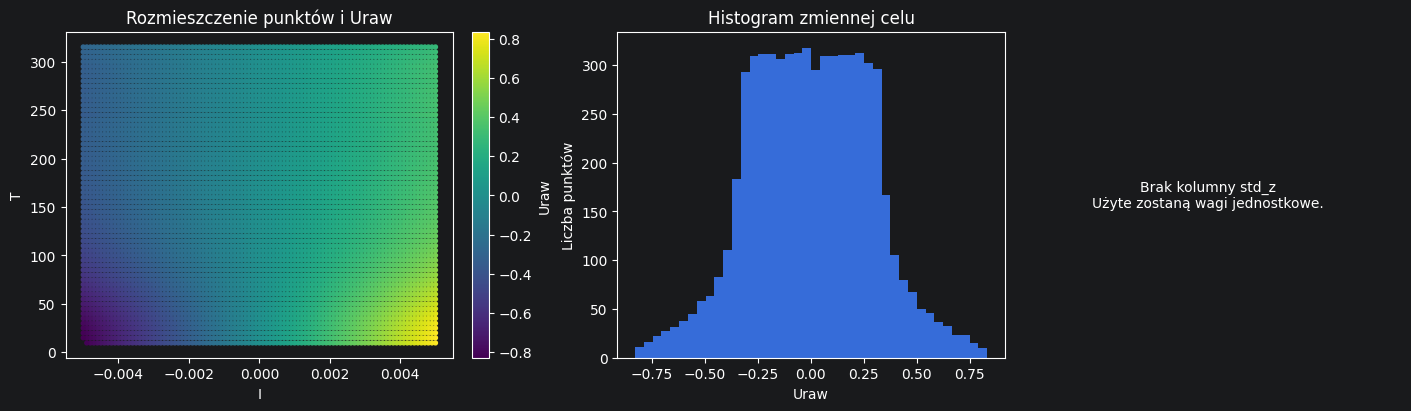

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

scatter = axes[0].scatter(x_raw, y_raw, c=z_raw, s=8, cmap="viridis")
axes[0].set_title(f"Rozmieszczenie punktów i {target_column}")
axes[0].set_xlabel(X_COLUMN)
axes[0].set_ylabel(Y_COLUMN)
fig.colorbar(scatter, ax=axes[0], label=target_column)

axes[1].hist(z_raw, bins=40)
axes[1].set_title("Histogram zmiennej celu")
axes[1].set_xlabel(target_column)
axes[1].set_ylabel("Liczba punktów")

if std_raw is not None:
    scatter_std = axes[2].scatter(x_raw, y_raw, c=std_raw, s=8, cmap="magma")
    axes[2].set_title(f"Przestrzenny rozkład {std_column}")
    axes[2].set_xlabel(X_COLUMN)
    axes[2].set_ylabel(Y_COLUMN)
    fig.colorbar(scatter_std, ax=axes[2], label=std_column)
else:
    axes[2].text(0.5, 0.5, "Brak kolumny std_z\nUżyte zostaną wagi jednostkowe.", ha="center", va="center")
    axes[2].set_axis_off()

plt.show()


### Jak interpretować tę sekcję

- Jeżeli punkty wypełniają prostokąt dziedziny równomiernie, tensorowa baza B-spline zwykle pracuje stabilnie.
- Jeżeli `std_z` rośnie wraz z wartością `|z|`, wagi nie są jednorodne i należy czytać metryki jako **ważone**.
- W przypadku benchmarku syntetycznego wykresy powinny być gładkie i uporządkowane. Gwałtowne artefakty wskazywałyby raczej na problem z danymi lub z przygotowaniem CSV niż z samą metodą P-spline.


## 5. Funkcje pomocnicze: preprocessing, baza B-spline i operatory różnicowe

Ta sekcja zawiera techniczny rdzeń przygotowania modelu.

### Dlaczego skalujemy dane?

W implementacji 2D wygodnie jest przeskalować obie osie wejściowe do przedziału `[0, 1]`. To daje trzy korzyści:

- łatwiej budować równomierną siatkę węzłów,
- wartości `lambda_x` i `lambda_y` są bardziej porównywalne między eksperymentami,
- pochodne względem osi surowych można odzyskać przez jawne zastosowanie reguły łańcuchowej.

Dodatkowo skaluje się także zmienną `z`. Dzięki temu:

- układ normalny jest lepiej uwarunkowany,
- tolerancja iteracyjna `tol` ma podobne znaczenie dla różnych danych,
- siatka hiperparametrów jest bardziej przenośna.

### Operacje `forward` i `inverse`

Preprocessor wykonuje trzy transformacje:

$$
\tilde{x}
=
\frac{x - x_{\min}}{x_{\max} - x_{\min}},
\qquad
\tilde{y}
=
\frac{y - y_{\min}}{y_{\max} - y_{\min}},
$$

oraz:

$$
\tilde{z}
=
\frac{z - \bar z}{s_z}.
$$

Jeżeli plik CSV zawiera `std_z`, to odchylenie standardowe również musi zostać przeskalowane tą samą liniową transformacją co `z`:

$$
\tilde{\sigma}_z
=
\frac{\sigma_z}{s_z}.
$$

Dzięki temu wagi:

$$
w_i
=
\frac{1}{\tilde{\sigma}_{z,i}^2}
$$

pozostają spójne z funkcją celu w przestrzeni modelowej.

### Skalowanie pochodnych

Model liczy pochodne w przestrzeni przeskalowanej. Aby wrócić do jednostek surowych, stosujemy regułę łańcuchową:

$$
\frac{\partial^{r+s}\hat f}{\partial x^r \partial y^s}
=
\frac{s_z}
{(x_{\max} - x_{\min})^r (y_{\max} - y_{\min})^s}
\frac{\partial^{r+s}\hat{\tilde f}}
{\partial \tilde x^r \partial \tilde y^s}.
$$

### Domena bazy B-spline

W tym notebooku **nie** zamieniamy po cichu punktów spoza domeny bazy na zera. Jeżeli po skalowaniu pojawią się wartości poza przedziałem `[0, 1]`, funkcja budująca bazę zgłosi błąd albo — jeżeli użytkownik świadomie włączy `CLIP_SCALED_INPUTS=True` — dane zostaną obcięte do domeny.

To rozróżnienie jest ważne metodologicznie, ponieważ predykcja poza domeną treningową B-splajnów nie jest wiarygodną ekstrapolacją.

In [5]:
@dataclass
class DataPreprocessor2D:
    """Scale x, y and z to numerically stable ranges.

    Why this matters:
    - x and y are mapped to [0, 1], which simplifies the knot construction.
    - z is standardized, which stabilizes the optimization and makes the tolerance
      and lambda grids more portable between datasets.
    - std_z, when present, is scaled consistently with z so that weighted losses
      remain internally coherent in the model space.
    - optional clipping can keep exploratory prediction inside the training domain,
      but it is disabled by default so that the notebook does not silently hide
      out-of-domain evaluation.
    """

    clip_scaled_inputs: bool = False
    x_min: float | None = None
    x_max: float | None = None
    y_min: float | None = None
    y_max: float | None = None
    z_mean: float | None = None
    z_std: float | None = None
    last_outside_domain_count_: int = 0

    def fit_transform(
        self,
        x: np.ndarray,
        y: np.ndarray,
        z: np.ndarray,
        std_z: np.ndarray | None = None,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        self.x_min = float(np.min(x))
        self.x_max = float(np.max(x))
        self.y_min = float(np.min(y))
        self.y_max = float(np.max(y))
        self.z_mean = float(np.mean(z))
        self.z_std = float(np.std(z))

        if np.isclose(self.x_max, self.x_min):
            raise ValueError("Zmienna x ma zerowy zakres. Nie można przeskalować osi x.")
        if np.isclose(self.y_max, self.y_min):
            raise ValueError("Zmienna y ma zerowy zakres. Nie można przeskalować osi y.")
        if np.isclose(self.z_std, 0.0):
            self.z_std = 1.0

        x_scaled = (np.asarray(x, dtype=float) - self.x_min) / (self.x_max - self.x_min)
        y_scaled = (np.asarray(y, dtype=float) - self.y_min) / (self.y_max - self.y_min)
        z_scaled = (np.asarray(z, dtype=float) - self.z_mean) / self.z_std

        if std_z is None:
            std_scaled = np.ones_like(z_scaled)
        else:
            std_scaled = np.asarray(std_z, dtype=float) / self.z_std
            positive_std = std_scaled[std_scaled > 0.0]
            fallback = float(np.median(positive_std)) if positive_std.size else 1.0
            std_scaled = np.where(std_scaled > 0.0, std_scaled, fallback)

        self.last_outside_domain_count_ = 0
        return x_scaled, y_scaled, z_scaled, std_scaled

    def transform_xy(
        self,
        x: np.ndarray,
        y: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray]:
        x_scaled = (np.asarray(x, dtype=float) - self.x_min) / (self.x_max - self.x_min)
        y_scaled = (np.asarray(y, dtype=float) - self.y_min) / (self.y_max - self.y_min)

        outside_domain = (
            (x_scaled < 0.0)
            | (x_scaled > 1.0)
            | (y_scaled < 0.0)
            | (y_scaled > 1.0)
        )
        self.last_outside_domain_count_ = int(np.sum(outside_domain))

        if self.clip_scaled_inputs and self.last_outside_domain_count_ > 0:
            x_scaled = np.clip(x_scaled, 0.0, 1.0)
            y_scaled = np.clip(y_scaled, 0.0, 1.0)

        return x_scaled, y_scaled

    def inverse_transform_z(self, z_scaled: np.ndarray) -> np.ndarray:
        return np.asarray(z_scaled, dtype=float) * self.z_std + self.z_mean

    def derivative_scale(self, order_x: int = 0, order_y: int = 0) -> float:
        """Return the chain-rule factor from model space to raw space."""
        range_x = self.x_max - self.x_min
        range_y = self.y_max - self.y_min
        return self.z_std / (range_x ** order_x) / (range_y ** order_y)


def make_open_uniform_knots(vmin: float, vmax: float, n_basis: int, degree: int) -> np.ndarray:
    """Create an open uniform knot vector.

    This is the standard P-spline choice:
    many evenly spaced B-splines and smoothness controlled by a penalty,
    rather than by delicate manual knot placement.
    """
    interior_count = n_basis - degree - 1
    interior = np.linspace(vmin, vmax, interior_count + 2)[1:-1] if interior_count > 0 else np.array([])
    return np.r_[
        np.repeat(vmin, degree + 1),
        interior,
        np.repeat(vmax, degree + 1),
    ]


def bspline_design_matrix(
    values: np.ndarray,
    knots: np.ndarray,
    degree: int,
    derivative_order: int = 0,
) -> np.ndarray:
    """Evaluate the full B-spline basis or its derivatives.

    The function returns a dense design matrix because the benchmark size
    is moderate and dense linear algebra stays simple and transparent in an
    educational notebook.
    """
    values = np.asarray(values, dtype=float)
    domain_min = float(knots[degree])
    domain_max = float(knots[-degree - 1])

    if np.any(values < domain_min - 1e-12) or np.any(values > domain_max + 1e-12):
        raise ValueError(
            "Wartości wejściowe wychodzą poza domenę bazy B-spline. "
            "Sprawdź skalowanie danych albo zakres walidacji."
        )

    values = np.clip(values, domain_min, domain_max)
    n_basis = len(knots) - degree - 1
    design = np.empty((len(values), n_basis), dtype=float)

    for basis_index in range(n_basis):
        coefficients = np.zeros(n_basis, dtype=float)
        coefficients[basis_index] = 1.0
        spline = BSpline(knots, coefficients, degree, extrapolate=False)
        if derivative_order > 0:
            spline = spline.derivative(derivative_order)
        design[:, basis_index] = spline(values)

    if np.any(~np.isfinite(design)):
        raise ValueError(
            "Macierz projektowa zawiera NaN albo inf. "
            "Najczęściej oznacza to wartości spoza domeny węzłów."
        )

    return design


def difference_matrix(n_coefficients: int, order: int) -> np.ndarray:
    """Create a finite-difference matrix of a chosen order."""
    matrix = np.eye(n_coefficients)
    for _ in range(order):
        matrix = np.diff(matrix, axis=0)
    return matrix


def row_tensor_product(Bx: np.ndarray, By: np.ndarray) -> np.ndarray:
    """Row-wise tensor product for scattered 2D data.

    For each observation i we create the row:
    kron(Bx[i, :], By[i, :])

    This matches the C-order convention used later when we reshape the
    coefficient vector back to a matrix with shape (n_basis_x, n_basis_y).
    """
    return np.einsum("ij,ik->ijk", Bx, By, optimize=True).reshape(Bx.shape[0], -1)


def weighted_mse(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    weights: np.ndarray | None = None,
) -> float:
    """Compute weighted mean squared error in raw space."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if weights is None:
        weights = np.ones_like(y_true)
    weights = np.asarray(weights, dtype=float)
    return float(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

## 5a. Kontrola algebraiczna konwencji `C-order`

Ta sekcja sprawdza, czy konstrukcja `row_tensor_product`, macierze kar `Px`, `Py` oraz operator monotoniczności `D1x_2d` odpowiadają deklarowanej konwencji `C-order`. Jest to test strukturalny równań, niezależny od konkretnego dopasowania.

W praktyce ten test odpowiada na cztery pytania:

1. czy `row_tensor_product(Bx, By)` jest zgodny z `np.kron(Bx[i], By[i])`,
2. czy `D1x_2d` naprawdę reprezentuje różnice po osi `x` w macierzy `A`,
3. czy `Px` odpowiada karze `||D2x A||_F^2`,
4. czy `Py` odpowiada karze `||A D2y^T||_F^2`.

Dla modeli 2D to bardzo ważne, ponieważ pomyłka między `C-order` i `F-order` daje kod, który może się uruchamiać, ale matematycznie odpowiadałby innemu modelowi niż ten opisany w Markdown.

In [6]:
rng = np.random.default_rng(123)

nx_test = 5
ny_test = 4
m_test = 7

Bx_test = rng.normal(size=(m_test, nx_test))
By_test = rng.normal(size=(m_test, ny_test))

B2_test = row_tensor_product(Bx_test, By_test)

for i in range(m_test):
    expected_row = np.kron(Bx_test[i, :], By_test[i, :])
    if not np.allclose(B2_test[i, :], expected_row):
        raise AssertionError("row_tensor_product nie odpowiada np.kron(Bx[i], By[i]) dla C-order.")

A_test = rng.normal(size=(nx_test, ny_test))
alpha_test = A_test.reshape(-1, order="C")

D1x_test = difference_matrix(nx_test, order=1)
D2x_test = difference_matrix(nx_test, order=2)
D2y_test = difference_matrix(ny_test, order=2)

D1x_2d_test = np.kron(D1x_test, np.eye(ny_test))
Px_test = np.kron(D2x_test.T @ D2x_test, np.eye(ny_test))
Py_test = np.kron(np.eye(nx_test), D2y_test.T @ D2y_test)

diff_x_from_operator = D1x_2d_test @ alpha_test
diff_x_from_matrix = np.diff(A_test, axis=0).reshape(-1, order="C")

if not np.allclose(diff_x_from_operator, diff_x_from_matrix):
    raise AssertionError("D1x_2d nie odpowiada różnicom po osi x dla macierzy A w C-order.")

rough_x_matrix = np.sum((D2x_test @ A_test) ** 2)
rough_x_operator = alpha_test @ Px_test @ alpha_test

if not np.allclose(rough_x_operator, rough_x_matrix):
    raise AssertionError("Px nie odpowiada karze ||D2x A||_F^2.")

rough_y_matrix = np.sum((A_test @ D2y_test.T) ** 2)
rough_y_operator = alpha_test @ Py_test @ alpha_test

if not np.allclose(rough_y_operator, rough_y_matrix):
    raise AssertionError("Py nie odpowiada karze ||A D2y^T||_F^2.")

print("OK: row_tensor_product, D1x_2d, Px i Py są zgodne z konwencją C-order.")

OK: row_tensor_product, D1x_2d, Px i Py są zgodne z konwencją C-order.


## 6. Klasa modelu: 2D constrained P-splines

Poniższa klasa implementuje jeden model 2D P-splines z opcjonalnym, parametrycznie sterowanym składnikiem monotoniczności. W typowym użyciu notebooka `monotone_x=True`, a siła constraintu jest kontrolowana przez `KAPPA`:

- `KAPPA > 0` włącza asymetryczną karę monotoniczności w osi `x`,
- `KAPPA = 0` zeruje składnik monotoniczności i ten sam estymator redukuje się do zwykłego 2D P-spline z karami gładkości.

Klasa obejmuje:

- preprocessing,
- budowę bazy tensorowej,
- kary gładkości w osiach `x` i `y`,
- asymetryczną karę monotoniczności w osi `x`,
- predykcję wartości funkcji,
- predykcję pochodnych cząstkowych.

### Ważny detal implementacyjny

Monotoniczność **nie** jest tutaj narzucona przez zewnętrzny solver QP ani przez twarde nierówności liniowe. Zamiast tego używamy iteracyjnej procedury IRLS / active-set:

1. dopasuj model dla bieżącej macierzy aktywnych naruszeń,
2. sprawdź, gdzie różnice współczynników w osi `x` są ujemne,
3. uaktualnij karę asymetryczną,
4. rozwiąż nowy układ normalny.

### Układ normalny w pojedynczej iteracji

Dla ustalonej macierzy aktywacji `V^(t)` rozwiązujemy układ:

$$
\left[
\mathbf{B}^T\mathbf{W}\mathbf{B}
+
\lambda_x^2\mathbf{P}_x
+
\lambda_y^2\mathbf{P}_y
+
\kappa
D_{1x,2D}^T
V^{(t)}
D_{1x,2D}
+
\varepsilon I
\right]
\boldsymbol{\alpha}^{(t+1)}
=
\mathbf{B}^T\mathbf{W}\mathbf{z}.
$$

Jeżeli `KAPPA = 0`, składnik:

$$
\kappa
D_{1x,2D}^T
V^{(t)}
D_{1x,2D}
$$

jest równy zero. To jest matematycznie uzasadniony sposób przejścia od wariantu constrained do zwykłego P-spline bez utrzymywania osobnej klasy albo osobnej gałęzi notebooka.


In [7]:
class ConstrainedPSpline2DRegressor:
    """Two-dimensional P-spline regressor with optional monotonicity in x.

    The model combines:
    - a tensor-product B-spline basis,
    - second-order difference penalties in x and y,
    - an asymmetric first-order penalty in x for monotonicity.

    The implementation is deliberately explicit and dense to keep the algebra
    visible. This is useful in an educational notebook where readability is
    more important than aggressive micro-optimization.
    """

    def __init__(
        self,
        n_basis_x: int,
        n_basis_y: int,
        degree: int,
        lambda_x: float,
        lambda_y: float,
        kappa: float = 1e6,
        monotone_x: bool = True,
        max_iter: int = 40,
        tol: float = 1e-6,
        clip_scaled_inputs: bool = False,
    ) -> None:
        self.n_basis_x = n_basis_x
        self.n_basis_y = n_basis_y
        self.degree = degree
        self.lambda_x = float(lambda_x)
        self.lambda_y = float(lambda_y)
        self.kappa = float(kappa)
        self.monotone_x = bool(monotone_x)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.clip_scaled_inputs = bool(clip_scaled_inputs)
        self.preprocessor = DataPreprocessor2D(clip_scaled_inputs=self.clip_scaled_inputs)

    def _basis_pair(
        self,
        x_scaled: np.ndarray,
        y_scaled: np.ndarray,
        order_x: int = 0,
        order_y: int = 0,
    ) -> tuple[np.ndarray, np.ndarray]:
        Bx = bspline_design_matrix(x_scaled, self.knots_x_, self.degree, derivative_order=order_x)
        By = bspline_design_matrix(y_scaled, self.knots_y_, self.degree, derivative_order=order_y)
        return Bx, By

    def fit(
        self,
        x: np.ndarray,
        y: np.ndarray,
        z: np.ndarray,
        std_z: np.ndarray | None = None,
    ) -> "ConstrainedPSpline2DRegressor":
        x_scaled, y_scaled, z_scaled, std_scaled = self.preprocessor.fit_transform(x, y, z, std_z)

        self.x_train_raw_ = np.asarray(x, dtype=float)
        self.y_train_raw_ = np.asarray(y, dtype=float)
        self.z_train_raw_ = np.asarray(z, dtype=float)
        self.z_train_scaled_ = z_scaled
        self.std_train_scaled_ = std_scaled
        self.weights_ = 1.0 / np.maximum(std_scaled, 1e-12) ** 2

        self.knots_x_ = make_open_uniform_knots(0.0, 1.0, self.n_basis_x, self.degree)
        self.knots_y_ = make_open_uniform_knots(0.0, 1.0, self.n_basis_y, self.degree)

        Bx_train, By_train = self._basis_pair(x_scaled, y_scaled, order_x=0, order_y=0)
        B_train = row_tensor_product(Bx_train, By_train)

        self.B_train_ = B_train
        self.Bx_train_ = Bx_train
        self.By_train_ = By_train

        BTWB = (B_train.T * self.weights_) @ B_train
        BTWz = B_train.T @ (self.weights_ * z_scaled)

        D2x = difference_matrix(self.n_basis_x, order=2)
        D2y = difference_matrix(self.n_basis_y, order=2)
        D1x = difference_matrix(self.n_basis_x, order=1)

        self.Px_ = np.kron(D2x.T @ D2x, np.eye(self.n_basis_y))
        self.Py_ = np.kron(np.eye(self.n_basis_x), D2y.T @ D2y)
        self.D1x_2d_ = np.kron(D1x, np.eye(self.n_basis_y))

        alpha = np.zeros(self.n_basis_x * self.n_basis_y, dtype=float)
        previous_active = np.zeros((self.n_basis_x - 1) * self.n_basis_y, dtype=float)
        self.converged_by_active_set_ = False

        for iteration in range(self.max_iter):
            if self.monotone_x:
                coefficient_differences_x = self.D1x_2d_ @ alpha
                active = (coefficient_differences_x < 0.0).astype(float)
                penalty_mono = self.D1x_2d_.T @ (active[:, None] * self.D1x_2d_)
            else:
                coefficient_differences_x = self.D1x_2d_ @ alpha
                active = np.zeros_like(coefficient_differences_x)
                penalty_mono = np.zeros((alpha.size, alpha.size), dtype=float)

            lhs = (
                BTWB
                + (self.lambda_x ** 2) * self.Px_
                + (self.lambda_y ** 2) * self.Py_
                + self.kappa * penalty_mono
                + 1e-10 * np.eye(alpha.size)
            )

            chol_factor, lower_flag = cho_factor(lhs, check_finite=False)
            updated_alpha = cho_solve((chol_factor, lower_flag), BTWz, check_finite=False)

            relative_change = np.linalg.norm(updated_alpha - alpha) / (np.linalg.norm(alpha) + 1e-12)
            active_set_stable = np.array_equal(active, previous_active)
            converged_by_coefficients = relative_change < self.tol

            alpha = updated_alpha

            if active_set_stable and converged_by_coefficients:
                previous_active = active.copy()
                self.converged_by_active_set_ = True
                break

            previous_active = active.copy()

        self.coefficients_ = alpha
        self.coefficients_matrix_ = alpha.reshape(self.n_basis_x, self.n_basis_y)
        self.active_mask_ = previous_active
        self.iterations_ = iteration + 1
        return self

    def predict_scaled(
        self,
        x: np.ndarray,
        y: np.ndarray,
        order_x: int = 0,
        order_y: int = 0,
    ) -> np.ndarray:
        x_scaled, y_scaled = self.preprocessor.transform_xy(x, y)
        Bx_eval, By_eval = self._basis_pair(x_scaled, y_scaled, order_x=order_x, order_y=order_y)
        B_eval = row_tensor_product(Bx_eval, By_eval)
        return B_eval @ self.coefficients_

    def predict(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        z_scaled = self.predict_scaled(x, y, order_x=0, order_y=0)
        return self.preprocessor.inverse_transform_z(z_scaled)

    def predict_derivative(
        self,
        x: np.ndarray,
        y: np.ndarray,
        order_x: int = 1,
        order_y: int = 0,
    ) -> np.ndarray:
        z_scaled = self.predict_scaled(x, y, order_x=order_x, order_y=order_y)
        scale = self.preprocessor.derivative_scale(order_x=order_x, order_y=order_y)
        return z_scaled * scale

    def training_objective_parts(self) -> dict[str, float]:
        prediction_scaled = self.B_train_ @ self.coefficients_
        residual = self.z_train_scaled_ - prediction_scaled

        rss = float(np.sum(self.weights_ * residual ** 2))
        rough_x = float(np.sum((difference_matrix(self.n_basis_x, 2) @ self.coefficients_matrix_) ** 2))
        rough_y = float(np.sum((self.coefficients_matrix_ @ difference_matrix(self.n_basis_y, 2).T) ** 2))

        coefficient_differences_x = self.D1x_2d_ @ self.coefficients_
        monotone_violation_norm = float(np.sum(np.minimum(coefficient_differences_x, 0.0) ** 2))
        monotone_penalty_weighted = float(self.kappa * monotone_violation_norm)

        return {
            "rss_scaled": rss,
            "roughness_x": rough_x,
            "roughness_y": rough_y,
            "monotone_violation_norm": monotone_violation_norm,
            "monotone_penalty_weighted": monotone_penalty_weighted,
            "active_constraints": float(np.sum(self.active_mask_)),
            "iterations": float(self.iterations_),
            "active_set_converged": float(self.converged_by_active_set_),
        }


def run_lambda_grid_search_2d(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    std_z: np.ndarray | None,
    n_basis_x: int,
    n_basis_y: int,
    degree: int,
    lambda_x_grid: np.ndarray,
    lambda_y_grid: np.ndarray,
    kappa: float,
    monotone_x: bool,
    n_splits: int,
    random_state: int,
) -> pd.DataFrame:
    """Evaluate a 2D lambda grid with K-fold cross-validation."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    std_z_array = None if std_z is None else np.asarray(std_z, dtype=float)

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows: list[dict[str, float]] = []

    for lambda_x in lambda_x_grid:
        for lambda_y in lambda_y_grid:
            train_losses = []
            valid_losses = []
            active_counts = []
            outside_counts = []
            failed_folds = 0

            for fold_index, (train_index, valid_index) in enumerate(splitter.split(x), start=1):
                estimator = ConstrainedPSpline2DRegressor(
                    n_basis_x=n_basis_x,
                    n_basis_y=n_basis_y,
                    degree=degree,
                    lambda_x=lambda_x,
                    lambda_y=lambda_y,
                    kappa=kappa,
                    monotone_x=monotone_x,
                    max_iter=MAX_ITER,
                    tol=TOL,
                    clip_scaled_inputs=CLIP_SCALED_INPUTS,
                )
                estimator.fit(
                    x=x[train_index],
                    y=y[train_index],
                    z=z[train_index],
                    std_z=None if std_z_array is None else std_z_array[train_index],
                )

                x_valid_scaled, y_valid_scaled = estimator.preprocessor.transform_xy(
                    x[valid_index],
                    y[valid_index],
                )
                outside_domain = (
                    (x_valid_scaled < 0.0)
                    | (x_valid_scaled > 1.0)
                    | (y_valid_scaled < 0.0)
                    | (y_valid_scaled > 1.0)
                )
                n_outside = int(np.sum(outside_domain))
                outside_counts.append(n_outside)

                try:
                    train_prediction = estimator.predict(x[train_index], y[train_index])
                    valid_prediction = estimator.predict(x[valid_index], y[valid_index])
                except ValueError:
                    failed_folds += 1
                    train_losses.append(np.inf)
                    valid_losses.append(np.inf)
                    active_counts.append(np.sum(estimator.active_mask_))
                    continue

                if std_z_array is None:
                    train_weights = np.ones_like(train_prediction)
                    valid_weights = np.ones_like(valid_prediction)
                else:
                    train_weights = 1.0 / np.maximum(std_z_array[train_index], 1e-12) ** 2
                    valid_weights = 1.0 / np.maximum(std_z_array[valid_index], 1e-12) ** 2

                train_loss = weighted_mse(z[train_index], train_prediction, train_weights)
                valid_loss = weighted_mse(z[valid_index], valid_prediction, valid_weights)

                train_losses.append(train_loss)
                valid_losses.append(valid_loss)
                active_counts.append(np.sum(estimator.active_mask_))

            row = {
                "lambda_x": float(lambda_x),
                "lambda_y": float(lambda_y),
                "train_loss_mean": float(np.mean(train_losses)),
                "train_loss_std": float(np.std(train_losses)),
                "validation_loss_mean": float(np.mean(valid_losses)),
                "validation_loss_std": float(np.std(valid_losses)),
                "active_constraints_mean": float(np.mean(active_counts)),
                "outside_domain_points_mean": float(np.mean(outside_counts)) if outside_counts else 0.0,
                "failed_folds": float(failed_folds),
            }

            for fold_position, (train_loss, valid_loss, outside_count) in enumerate(
                zip(train_losses, valid_losses, outside_counts),
                start=1,
            ):
                row[f"train_fold_{fold_position}"] = float(train_loss)
                row[f"valid_fold_{fold_position}"] = float(valid_loss)
                row[f"outside_fold_{fold_position}"] = float(outside_count)

            rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["validation_loss_mean", "lambda_x", "lambda_y"],
        ascending=[True, True, True],
    ).reset_index(drop=True)


def metric_table_against_benchmark(
    df_reference: pd.DataFrame,
    estimator: ConstrainedPSpline2DRegressor,
    label: str,
) -> pd.DataFrame:
    """Compare fitted values and derivatives with available true_* columns."""
    metric_specs = [
        ("true_z", 0, 0, "z"),
        ("true_dz_dx", 1, 0, "dz/dx"),
        ("true_dz_dy", 0, 1, "dz/dy"),
        ("true_d2z_dx2", 2, 0, "d2z/dx2"),
        ("true_d2z_dxdy", 1, 1, "d2z/dxdy"),
        ("true_d2z_dy2", 0, 2, "d2z/dy2"),
    ]

    rows = []
    for reference_column, order_x, order_y, name in metric_specs:
        if reference_column not in df_reference.columns:
            continue

        if order_x == 0 and order_y == 0:
            prediction = estimator.predict(df_reference[X_COLUMN].to_numpy(), df_reference[Y_COLUMN].to_numpy())
        else:
            prediction = estimator.predict_derivative(
                df_reference[X_COLUMN].to_numpy(),
                df_reference[Y_COLUMN].to_numpy(),
                order_x=order_x,
                order_y=order_y,
            )

        truth = df_reference[reference_column].to_numpy(dtype=float)
        mae = float(np.mean(np.abs(prediction - truth)))
        rmse = float(np.sqrt(np.mean((prediction - truth) ** 2)))
        rows.append(
            {
                "model": label,
                "quantity": name,
                "reference_column": reference_column,
                "mae": mae,
                "rmse": rmse,
            }
        )

    return pd.DataFrame(rows)


def finite_difference_check_model_derivatives(
    estimator: ConstrainedPSpline2DRegressor,
    x_values: np.ndarray,
    y_values: np.ndarray,
    h_x: float = 1e-5,
    h_y: float = 1e-5,
) -> pd.DataFrame:
    """Diagnostically compare analytic spline derivatives with finite differences."""
    rows = []

    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    for y0 in y_values:
        x0 = x_values
        dzdx_num = (
            estimator.predict(x0 + h_x, np.full_like(x0, y0))
            - estimator.predict(x0 - h_x, np.full_like(x0, y0))
        ) / (2.0 * h_x)

        dzdx_an = estimator.predict_derivative(
            x0,
            np.full_like(x0, y0),
            order_x=1,
            order_y=0,
        )

        rows.append(
            {
                "quantity": "dz/dx",
                "slice": f"y={y0:.4f}",
                "max_abs_error": float(np.max(np.abs(dzdx_num - dzdx_an))),
            }
        )

    for x0 in x_values[:: max(1, len(x_values) // 5)]:
        y0 = y_values
        dzdy_num = (
            estimator.predict(np.full_like(y0, x0), y0 + h_y)
            - estimator.predict(np.full_like(y0, x0), y0 - h_y)
        ) / (2.0 * h_y)

        dzdy_an = estimator.predict_derivative(
            np.full_like(y0, x0),
            y0,
            order_x=0,
            order_y=1,
        )

        rows.append(
            {
                "quantity": "dz/dy",
                "slice": f"x={x0:.4f}",
                "max_abs_error": float(np.max(np.abs(dzdy_num - dzdy_an))),
            }
        )

    return pd.DataFrame(rows)

## 7. Hyperparameter search dla `lambda_x` i `lambda_y`

Parametry `lambda_x` i `lambda_y` regulują kompromis między dopasowaniem do danych a gładkością powierzchni.

W funkcji celu występują jako:

$$
\lambda_x^2\boldsymbol{\alpha}^T\mathbf{P}_x\boldsymbol{\alpha}
+
\lambda_y^2\boldsymbol{\alpha}^T\mathbf{P}_y\boldsymbol{\alpha}.
$$

Interpretacja:

- większe `lambda_x` silniej wygładza strukturę modelu w osi `x`,
- większe `lambda_y` silniej wygładza strukturę modelu w osi `y`,
- zbyt małe wartości mogą prowadzić do nadmiernego dopasowania szumu,
- zbyt duże wartości mogą zbyt mocno spłaszczyć powierzchnię i pochodne.

W tej sekcji wykonujemy walidację krzyżową na siatce wartości `lambda_x` i `lambda_y`. Dla każdego zestawu parametrów model jest uczony na foldzie treningowym i oceniany na foldzie walidacyjnym.

### Ważna uwaga o `KAPPA`

`KAPPA` nie jest tutaj przeszukiwane siatkowo. Jest parametrem konfiguracji modelu:

- `KAPPA > 0` oznacza aktywną asymetryczną karę monotoniczności,
- `KAPPA = 0` oznacza zwykły P-spline bez constraintu monotoniczności.

### Uwaga o domenie walidacji krzyżowej

Preprocessor jest dopasowywany na foldzie treningowym. Dlatego notebook kontroluje, czy punkty walidacyjne po przeskalowaniu wychodzą poza przedział `[0, 1]`. Taka sytuacja jest sygnałem ostrzegawczym, ponieważ B-splajny nie są wiarygodnym narzędziem ekstrapolacji poza domeną treningową.


In [8]:

search_results = run_lambda_grid_search_2d(
    x=x_raw,
    y=y_raw,
    z=z_raw,
    std_z=std_raw,
    n_basis_x=N_BASIS_X,
    n_basis_y=N_BASIS_Y,
    degree=POLYNOMIAL_DEGREE,
    lambda_x_grid=LAMBDA_X_GRID,
    lambda_y_grid=LAMBDA_Y_GRID,
    kappa=KAPPA,
    monotone_x=True,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

best_params = search_results.iloc[0].to_dict()

print("Najlepszy zestaw hiperparametrów:")
print(best_params)

display(search_results.head(10))


Najlepszy zestaw hiperparametrów:
{'lambda_x': 0.3, 'lambda_y': 0.03, 'train_loss_mean': 2.2912902642844187e-06, 'train_loss_std': 3.661790925226686e-08, 'validation_loss_mean': 2.5363009505162725e-06, 'validation_loss_std': 1.805666955324151e-07, 'active_constraints_mean': 0.0, 'outside_domain_points_mean': 0.0, 'failed_folds': 0.0, 'train_fold_1': 2.239911390976374e-06, 'valid_fold_1': 2.8240237552819263e-06, 'outside_fold_1': 0.0, 'train_fold_2': 2.3298726240276088e-06, 'valid_fold_2': 2.3796860870085147e-06, 'outside_fold_2': 0.0, 'train_fold_3': 2.2991211851683535e-06, 'valid_fold_3': 2.4893301004801817e-06, 'outside_fold_3': 0.0, 'train_fold_4': 2.3291447824309508e-06, 'valid_fold_4': 2.336176648902994e-06, 'outside_fold_4': 0.0, 'train_fold_5': 2.258401338818806e-06, 'valid_fold_5': 2.652288160907746e-06, 'outside_fold_5': 0.0}


,lambda_x,lambda_y,train_loss_mean,train_loss_std,validation_loss_mean,validation_loss_std,active_constraints_mean,outside_domain_points_mean,failed_folds,train_fold_1,...,outside_fold_2,train_fold_3,valid_fold_3,outside_fold_3,train_fold_4,valid_fold_4,outside_fold_4,train_fold_5,valid_fold_5,outside_fold_5
0,0.3,0.0300,0.000002,3.661791e-08,0.000003,1.805667e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
1,0.3,0.0100,0.000002,3.662451e-08,0.000003,1.800934e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
2,0.3,0.0030,0.000002,3.662576e-08,0.000003,1.800410e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
3,0.3,0.0010,0.000002,3.662588e-08,0.000003,1.800364e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
4,0.3,0.0003,0.000002,3.662589e-08,0.000003,1.800359e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
5,0.3,0.0001,0.000002,3.662589e-08,0.000003,1.800359e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000002,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
6,0.3,0.1000,0.000002,3.693086e-08,0.000003,1.855019e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000003,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
7,0.1,0.1000,0.000002,3.696113e-08,0.000003,1.900114e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000003,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
8,0.1,0.0300,0.000002,3.666927e-08,0.000003,1.843048e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000003,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0
9,0.1,0.0100,0.000002,3.666082e-08,0.000003,1.837632e-07,0.0,0.0,0.0,0.000002,...,0.0,0.000002,0.000003,0.0,0.000002,0.000002,0.0,0.000002,0.000003,0.0


### Jak interpretować tabelę `search_results`

Najważniejsze kolumny:

- `lambda_x`, `lambda_y` — siła wygładzania w obu osiach,
- `train_loss_mean` — średni błąd treningowy,
- `validation_loss_mean` — średni błąd walidacyjny,
- `validation_loss_std` — zmienność tego błędu między foldami,
- `active_constraints_mean` — ile ograniczeń monotoniczności przeciętnie było aktywnych,
- `outside_domain_points_mean` — ile punktów walidacyjnych przeciętnie wychodziło poza domenę treningową po skalowaniu.

### Kryterium wyboru

Tak jak w 1D, **ostatecznym kryterium wyboru nie jest minimum składnika kary ani minimum błędu treningowego**. Wybieramy minimum `validation_loss_mean`, ponieważ to ono najlepiej odzwierciedla kompromis między elastycznością a generalizacją.

Jeżeli `outside_domain_points_mean` jest dodatnie, należy pamiętać, że część walidacji dotyczy punktów poza domeną treningową lokalnej bazy. Wtedy wyniki CV trzeba interpretować ostrożniej.

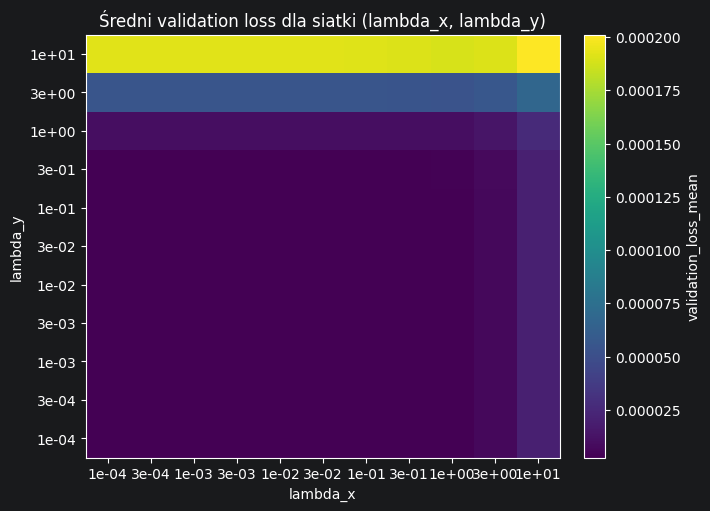

In [9]:

pivot_cv = search_results.pivot(index="lambda_y", columns="lambda_x", values="validation_loss_mean")

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
image = ax.imshow(
    pivot_cv.sort_index(ascending=False).to_numpy(),
    aspect="auto",
    cmap="viridis",
)
ax.set_title("Średni validation loss dla siatki (lambda_x, lambda_y)")
ax.set_xlabel("lambda_x")
ax.set_ylabel("lambda_y")
ax.set_xticks(range(len(pivot_cv.columns)))
ax.set_xticklabels([f"{value:.0e}" for value in pivot_cv.columns])
ax.set_yticks(range(len(pivot_cv.index)))
ax.set_yticklabels([f"{value:.0e}" for value in sorted(pivot_cv.index, reverse=True)])
fig.colorbar(image, ax=ax, label="validation_loss_mean")
plt.show()


### Jak czytać mapę walidacji krzyżowej

- Ciemniejszy obszar oznacza mniejszy błąd walidacyjny i lepszy kompromis modelu.
- Jeżeli dobre wyniki układają się w pas, oznacza to, że model jest dość odporny na umiarkowane zmiany `lambda`.
- Jeżeli minimum jest ostre i izolowane, dopasowanie jest bardziej czułe na strojenie.
- W benchmarku o znanej prawdzie szczególnie interesujące jest to, czy parametry wybrane przez CV dają potem także dobre pochodne.
- Jeżeli najlepszy model ma dużo punktów `outside_domain_points_mean`, warto rozważyć bardziej kontrolowany podział danych lub clipping tylko jako świadomą decyzję diagnostyczną.

## 8. Dopasowanie końcowe jednego modelu 2D P-splines

W tej sekcji dopasowujemy **jeden finalny model** `ConstrainedPSpline2DRegressor` z najlepszymi wartościami `lambda_x` i `lambda_y` znalezionymi w walidacji krzyżowej.

Model jest traktowany jako wariant constrained, ponieważ `monotone_x=True`. Siła constraintu zależy wyłącznie od `KAPPA`:

- gdy `KAPPA > 0`, model zawiera asymetryczną karę monotoniczności,
- gdy `KAPPA = 0`, kara monotoniczności znika i ten sam kod działa jak standardowy 2D P-spline.

Dzięki temu notebook jest prostszy: nie porównuje dwóch osobnych estymatorów, tylko raportuje predykcje jednego modelu używanego w dalszej analizie.


In [10]:
best_lambda_x = float(best_params["lambda_x"])
best_lambda_y = float(best_params["lambda_y"])

constrained_estimator = ConstrainedPSpline2DRegressor(
    n_basis_x=N_BASIS_X,
    n_basis_y=N_BASIS_Y,
    degree=POLYNOMIAL_DEGREE,
    lambda_x=best_lambda_x,
    lambda_y=best_lambda_y,
    kappa=KAPPA,
    monotone_x=True,
    max_iter=MAX_ITER,
    tol=TOL,
    clip_scaled_inputs=CLIP_SCALED_INPUTS,
)
constrained_estimator.fit(x=x_raw, y=y_raw, z=z_raw, std_z=std_raw)

training_summary = pd.DataFrame(
    [
        {
            "model": "constrained" if KAPPA > 0 else "p_spline_kappa_0",
            "kappa": KAPPA,
            "n_basis_x": N_BASIS_X,
            "n_basis_y": N_BASIS_Y,
            "n_coefficients": N_BASIS_X * N_BASIS_Y,
            "basis_selection_mode": basis_selection_info["basis_selection_mode"],
            "target_coefficient_fraction": TARGET_COEFFICIENT_FRACTION,
            "selected_coefficient_fraction": basis_selection_info["selected_coefficient_fraction"],
            **constrained_estimator.training_objective_parts(),
        }
    ]
)
display(training_summary)


,model,kappa,n_basis_x,n_basis_y,n_coefficients,basis_selection_mode,target_coefficient_fraction,selected_coefficient_fraction,rss_scaled,roughness_x,roughness_y,monotone_violation_norm,monotone_penalty_weighted,active_constraints,iterations,active_set_converged
0,constrained,1000000.0,24,13,312,automatic_fraction,0.05,0.049832,0.179197,0.158817,3.007728,0.0,0.0,0.0,2.0,1.0


### Interpretacja tabeli dopasowania końcowego

Tabela `training_summary` rozdziela kilka składników jakości dopasowania:

- `rss_scaled` — ważony składnik reszt w przestrzeni modelowej,
- `roughness_x`, `roughness_y` — kary gładkości odpowiadające `||D2x A||_F^2` i `||A D2y^T||_F^2`,
- `monotone_violation_norm` — surowa norma naruszeń monotoniczności, jeszcze bez mnożnika `kappa`,
- `monotone_penalty_weighted` — rzeczywisty składnik funkcji celu po przemnożeniu przez `kappa`,
- `active_constraints` — liczba aktywnych naruszeń w ostatniej iteracji IRLS,
- `active_set_converged` — informacja, czy aktywny zbiór ograniczeń ustabilizował się przed zatrzymaniem.

To rozróżnienie jest ważne: sama surowa norma naruszeń mówi, jak duży jest problem geometryczny, a wersja ważona mówi, jaki jest realny wkład tej części do funkcji celu.

## 9. Siatka predykcyjna do wizualizacji powierzchni i pochodnych

Dane wejściowe mogą być traktowane jako punkty rozproszone, ale do interpretacji modelu wygodniej jest budować osobną regularną siatkę predykcji.


In [11]:
x_grid = np.linspace(np.min(x_raw), np.max(x_raw), PREDICTION_GRID_X)
y_grid = np.linspace(np.min(y_raw), np.max(y_raw), PREDICTION_GRID_Y)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing="xy")
grid_points = pd.DataFrame(
    {
        "x": X_grid.ravel(),
        "y": Y_grid.ravel(),
    }
)

# Dla dalszych wykresów 3D dodajemy także aliasy zgodne z rzeczywistymi nazwami kolumn wejściowych.
# Przykład: dla danych realnych X_COLUMN="I", Y_COLUMN="T", więc grid_points dostaje kolumny "I" i "T".
# Nie zastępuje to technicznych kolumn "x" i "y", które pozostają wygodne w diagnostyce modelu.
if X_COLUMN not in grid_points.columns:
    grid_points[X_COLUMN] = grid_points["x"]
if Y_COLUMN not in grid_points.columns:
    grid_points[Y_COLUMN] = grid_points["y"]

grid_x = grid_points["x"].to_numpy()
grid_y = grid_points["y"].to_numpy()

grid_points["pred_z"] = constrained_estimator.predict(grid_x, grid_y)
grid_points["pred_dz_dx"] = constrained_estimator.predict_derivative(grid_x, grid_y, order_x=1, order_y=0)
grid_points["pred_dz_dy"] = constrained_estimator.predict_derivative(grid_x, grid_y, order_x=0, order_y=1)
grid_points["pred_d2z_dx2"] = constrained_estimator.predict_derivative(grid_x, grid_y, order_x=2, order_y=0)
grid_points["pred_d2z_dxdy"] = constrained_estimator.predict_derivative(grid_x, grid_y, order_x=1, order_y=1)
grid_points["pred_d2z_dy2"] = constrained_estimator.predict_derivative(grid_x, grid_y, order_x=0, order_y=2)

display(grid_points.head())


,x,y,I,T,pred_z,pred_dz_dx,pred_dz_dy,pred_d2z_dx2,pred_d2z_dxdy,pred_d2z_dy2
0,-0.005000,9.67834,-0.005000,9.67834,-0.835747,194.204702,0.000669,-119509.728615,-2.271831,0.000158
1,-0.004917,9.67834,-0.004917,9.67834,-0.819956,185.059646,0.000510,-99971.602401,-1.574368,0.000165
2,-0.004833,9.67834,-0.004833,9.67834,-0.804859,177.542768,0.000403,-80433.476186,-1.005990,0.000169
3,-0.004750,9.67834,-0.004750,9.67834,-0.790320,171.654067,0.000339,-60895.349971,-0.566698,0.000170
4,-0.004667,9.67834,-0.004667,9.67834,-0.776204,167.393543,0.000305,-41357.223756,-0.256492,0.000169


## 10. Wizualizacja powierzchni dopasowanej

Oglądamy dane wejściowe oraz powierzchnię przewidzianą przez finalny model 2D P-splines.

Ta sekcja odpowiada na pytanie, czy model odtwarza globalną geometrię danych wejściowych. Diagnostyka monotoniczności i pochodnych znajduje się w kolejnych sekcjach.


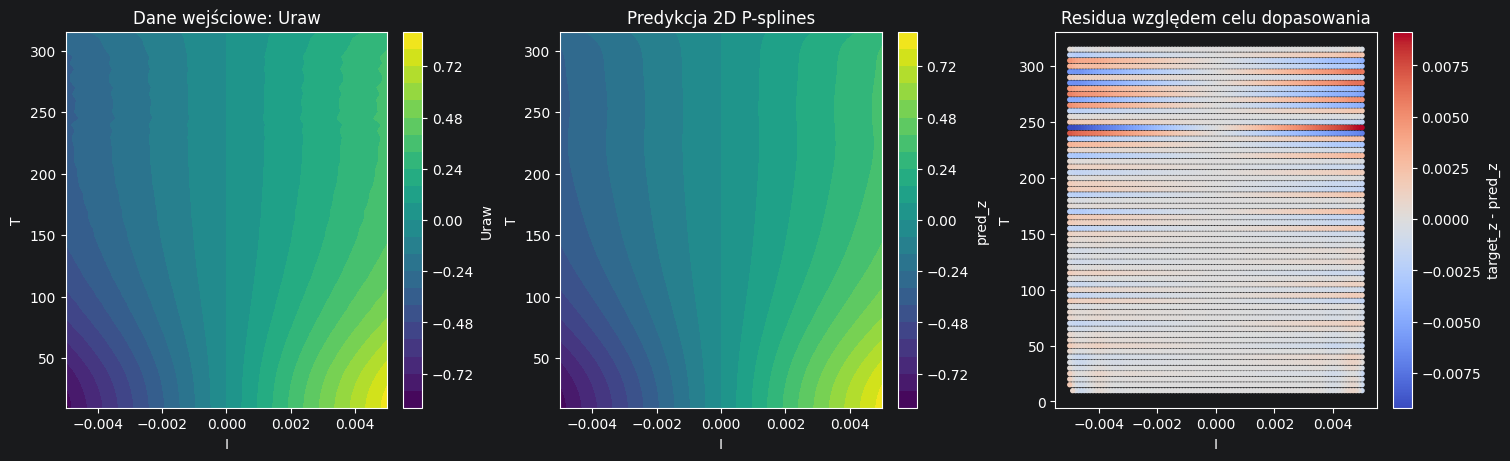

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

levels_data = 20

contour = axes[0].tricontourf(x_raw, y_raw, z_raw, levels=levels_data, cmap="viridis")
axes[0].set_title(f"Dane wejściowe: {target_column}")
axes[0].set_xlabel(X_COLUMN)
axes[0].set_ylabel(Y_COLUMN)
fig.colorbar(contour, ax=axes[0], label=target_column)

pred_grid = grid_points["pred_z"].to_numpy().reshape(Y_grid.shape)
contour = axes[1].contourf(X_grid, Y_grid, pred_grid, levels=levels_data, cmap="viridis")
axes[1].set_title("Predykcja 2D P-splines")
axes[1].set_xlabel(X_COLUMN)
axes[1].set_ylabel(Y_COLUMN)
fig.colorbar(contour, ax=axes[1], label="pred_z")

residual_at_points = z_raw - constrained_estimator.predict(x_raw, y_raw)
scatter = axes[2].scatter(x_raw, y_raw, c=residual_at_points, s=8, cmap="coolwarm")
axes[2].set_title("Residua względem celu dopasowania")
axes[2].set_xlabel(X_COLUMN)
axes[2].set_ylabel(Y_COLUMN)
fig.colorbar(scatter, ax=axes[2], label="target_z - pred_z")

plt.show()


### Jak interpretować powierzchnię

- Panel danych wejściowych pokazuje kolumnę faktycznie używaną do dopasowania: zwykle `observed_z`, a awaryjnie `true_z`.
- Panel predykcji pokazuje wygładzoną powierzchnię 2D P-splines.
- Panel residuów pokazuje różnicę między celem dopasowania a predykcją modelu.

Jeżeli `KAPPA > 0`, predykcja dodatkowo uwzględnia asymetryczną karę monotoniczności względem osi `x`. Jeżeli `KAPPA = 0`, ten sam notebook działa jak zwykły P-spline bez constraintu monotoniczności.


## 11. Diagnostyka monotoniczności względem x

To jest centralna sekcja dla modelu constrained.

Sprawdzamy monotoniczność na dwa sposoby:

1. w przestrzeni współczynników — przez różnice `D1x a`,
2. w przestrzeni funkcji — przez przewidywaną pochodną `dz/dx`.

Pierwsze podejście mówi, jak działa kara wewnątrz modelu.  
Drugie podejście mówi, czy w praktyce otrzymujemy powierzchnię rosnącą w osi `x`.


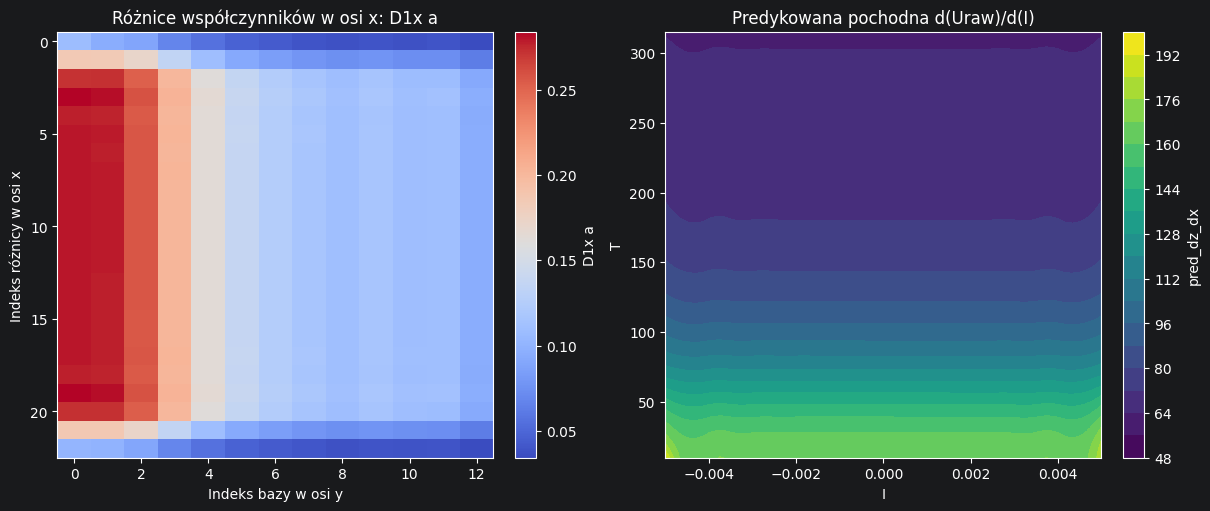

Minimalna wartość dz/dx na siatce: 55.71222360
Udział punktów siatki z dz/dx < 0: 0.00000000%
Minimalna różnica współczynników D1x a: 3.42186469e-02
Liczba istotnie ujemnych różnic współczynników: 0


In [13]:
coefficient_diff_x = (constrained_estimator.D1x_2d_ @ constrained_estimator.coefficients_).reshape(
    N_BASIS_X - 1,
    N_BASIS_Y,
)
dz_dx_grid = grid_points["pred_dz_dx"].to_numpy().reshape(Y_grid.shape)

fig, axes = plt.subplots(1, 2, figsize=PLOT_FIGSIZE_WIDE, constrained_layout=True)

image = axes[0].imshow(coefficient_diff_x, aspect="auto", cmap="coolwarm")
axes[0].set_title("Różnice współczynników w osi x: D1x a")
axes[0].set_xlabel("Indeks bazy w osi y")
axes[0].set_ylabel("Indeks różnicy w osi x")
fig.colorbar(image, ax=axes[0], label="D1x a")

contour = axes[1].contourf(X_grid, Y_grid, dz_dx_grid, levels=20, cmap="viridis")
axes[1].set_title(f"Predykowana pochodna d({target_column})/d({X_COLUMN})")
axes[1].set_xlabel(X_COLUMN)
axes[1].set_ylabel(Y_COLUMN)
fig.colorbar(contour, ax=axes[1], label="pred_dz_dx")

plt.show()

min_dz_dx = float(np.min(dz_dx_grid))
fraction_negative_dz_dx = float(np.mean(dz_dx_grid < 0.0))
coefficient_differences = constrained_estimator.D1x_2d_ @ constrained_estimator.coefficients_
min_coefficient_diff = float(np.min(coefficient_differences))
n_negative_coefficient_diffs = int(np.sum(coefficient_differences < -1e-10))

print(f"Minimalna wartość dz/dx na siatce: {min_dz_dx:.8f}")
print(f"Udział punktów siatki z dz/dx < 0: {fraction_negative_dz_dx:.8%}")
print(f"Minimalna różnica współczynników D1x a: {min_coefficient_diff:.8e}")
print(f"Liczba istotnie ujemnych różnic współczynników: {n_negative_coefficient_diffs}")


### Jak interpretować monotoniczność

- Pole `D1x a` sprawdza warunek współczynnikowy. Jeżeli wszystkie wartości są nieujemne, wystarczający warunek monotoniczności współczynnikowej jest spełniony numerycznie.
- Pole `dz/dx` sprawdza monotoniczność już na poziomie samej powierzchni, czyli w przestrzeni ciągłej.
- Jeśli `n_negative_coefficient_diffs = 0`, warunek wystarczający monotoniczności współczynnikowej jest spełniony numerycznie.
- Jeżeli pojawiają się pojedyncze bardzo małe wartości ujemne rzędu tolerancji, zwykle wynikają z numeryki i trzeba je interpretować ostrożnie.
- Jeżeli widoczne są wyraźne ujemne różnice współczynników albo duże obszary z `dz/dx < 0`, należy zwiększyć `KAPPA` albo zmienić sposób wymuszania ograniczenia.

## 12. Diagnostyka residuów

Residua pokazują, gdzie model niedopasowuje lub nadmiernie dopasowuje powierzchnię.

W dobrze zachowującym się modelu:
- residua nie powinny wykazywać wyraźnych struktur przestrzennych,
- histogram reszt powinien być skupiony wokół zera,
- brak systematycznych pasów lub grzbietów sugeruje, że baza i kary są dobrze dobrane.


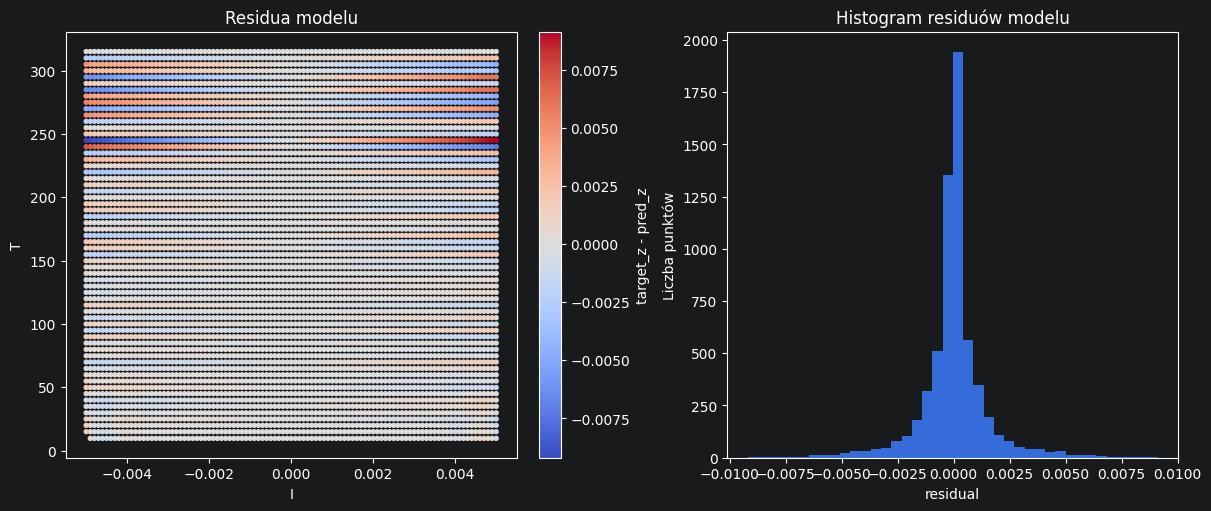

In [14]:
df_predictions_at_points = df[[X_COLUMN, Y_COLUMN]].copy()
df_predictions_at_points["target_z"] = z_raw
df_predictions_at_points["pred_z"] = constrained_estimator.predict(x_raw, y_raw)
df_predictions_at_points["residual_target"] = df_predictions_at_points["target_z"] - df_predictions_at_points["pred_z"]

fig, axes = plt.subplots(1, 2, figsize=PLOT_FIGSIZE_WIDE, constrained_layout=True)

scatter = axes[0].scatter(
    df_predictions_at_points[X_COLUMN],
    df_predictions_at_points[Y_COLUMN],
    c=df_predictions_at_points["residual_target"],
    s=8,
    cmap="coolwarm",
)
axes[0].set_title("Residua modelu")
axes[0].set_xlabel(X_COLUMN)
axes[0].set_ylabel(Y_COLUMN)
fig.colorbar(scatter, ax=axes[0], label="target_z - pred_z")

axes[1].hist(df_predictions_at_points["residual_target"], bins=40)
axes[1].set_title("Histogram residuów modelu")
axes[1].set_xlabel("residual")
axes[1].set_ylabel("Liczba punktów")

plt.show()


### Jak czytać residua

- Jeżeli mapa reszt ma strukturę przestrzenną, model nie wychwycił całej geometrii powierzchni.
- Jeżeli residua są małe i bez wyraźnego wzoru, dopasowanie jest dobre.
- W benchmarku syntetycznym bardzo małe residua zwykle oznaczają, że baza jest wystarczająco bogata, a regularizacja nie jest zbyt silna.


## 13. Porównanie z benchmarkiem analitycznym

Ta sekcja jest wykonywana tylko wtedy, gdy plik CSV zawiera kolumny `true_*`.

Dla danych syntetycznych kolumny `true_*` pozwalają ocenić nie tylko dopasowanie samej wartości funkcji `z`, lecz także jakość rekonstrukcji pochodnych cząstkowych:

- `z`,
- `dz/dx`,
- `dz/dy`,
- `d2z/dx2`,
- `d2z/dxdy`,
- `d2z/dy2`.

Dla danych rzeczywistych, takich jak pomiary `I`, `T`, `Uraw`, wartości prawdziwe zwykle nie są znane. Wtedy notebook pomija tę sekcję bez błędu i nadal zapisuje predykcje modelu do pliku wynikowego.


In [15]:
if has_benchmark:
    benchmark_metrics = metric_table_against_benchmark(df, constrained_estimator, label="model")
    display(benchmark_metrics)
else:
    benchmark_metrics = pd.DataFrame()
    print("Brak kolumn true_*. Pomijam benchmark ilościowy.")


Brak kolumn true_*. Pomijam benchmark ilościowy.


### Jak interpretować tabelę benchmarkową

- `mae` mówi o przeciętnym bezwzględnym błędzie.
- `rmse` mocniej karze większe lokalne odchylenia.
- Dla pochodnych drugiego rzędu błędy zwykle są większe niż dla samej funkcji.
- Szczególnie ważna jest jakość `dz/dx`, bo ta pochodna jest bezpośrednio powiązana z warunkiem monotoniczności.

Tabela dotyczy jednego finalnego modelu. Jeżeli chcesz sprawdzić, jak model zachowuje się bez constraintu, ustaw `KAPPA = 0` i uruchom notebook ponownie.


## 14. Wizualizacja pochodnych cząstkowych modelu

W tej sekcji oglądamy najważniejsze pochodne modelu:

- `pred_dz_dx` — pochodna względem osi modelowej `x`, czyli kolumny `X_COLUMN`,
- `pred_dz_dy` — pochodna względem osi modelowej `y`, czyli kolumny `Y_COLUMN`,
- `pred_d2z_dx2` — lokalna krzywizna w osi `x`,
- `pred_d2z_dxdy` — pochodna mieszana, czyli jak lokalny wzrost względem `x` zmienia się w kierunku `y`,
- `pred_d2z_dy2` — krzywizna w osi `y`.

Dla danych rzeczywistych, np. przy mapowaniu `x = I`, `y = T`, `z = Uraw`, pochodne należy interpretować odpowiednio jako pochodne modelu względem prądu i temperatury.

W przestrzeni modelowej pochodne mają postać:

$$
\frac{\partial^{r+s}\tilde f}{\partial \tilde x^r \partial \tilde y^s}
=
\sum_{p=1}^{n_x}
\sum_{q=1}^{n_y}
\alpha_{pq}
B_p^{(r)}(\tilde x)
C_q^{(s)}(\tilde y).
$$

Po przejściu do skali surowej obowiązuje reguła:

$$
\frac{\partial^{r+s}\hat f}{\partial x^r \partial y^s}
=
\frac{s_z}
{(x_{\max} - x_{\min})^r (y_{\max} - y_{\min})^s}
\frac{\partial^{r+s}\tilde f}
{\partial \tilde x^r \partial \tilde y^s}.
$$

Dla benchmarku analitycznego pochodne są znane, więc można później porównywać nie tylko ich liczby, ale także całe pola. Dla danych rzeczywistych ta sekcja dostarcza predykcji pochodnych modelu, bez benchmarku `true_*`.


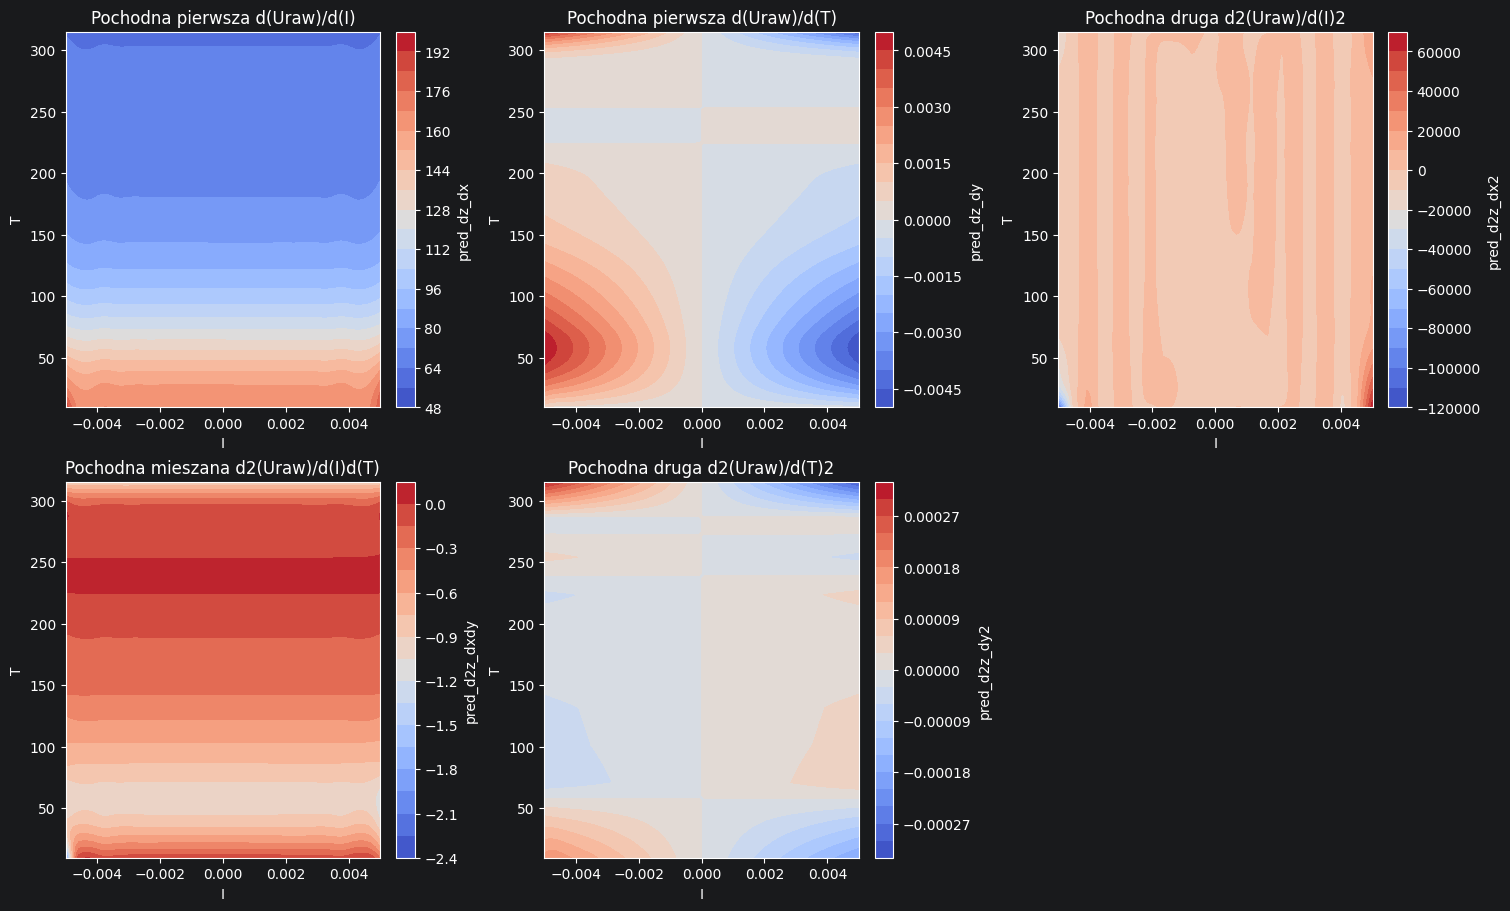

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

derivative_specs = [
    ("pred_dz_dx", f"Pochodna pierwsza d({target_column})/d({X_COLUMN})"),
    ("pred_dz_dy", f"Pochodna pierwsza d({target_column})/d({Y_COLUMN})"),
    ("pred_d2z_dx2", f"Pochodna druga d2({target_column})/d({X_COLUMN})2"),
    ("pred_d2z_dxdy", f"Pochodna mieszana d2({target_column})/d({X_COLUMN})d({Y_COLUMN})"),
    ("pred_d2z_dy2", f"Pochodna druga d2({target_column})/d({Y_COLUMN})2"),
]

for axis, (column, title) in zip(axes.ravel(), derivative_specs):
    surface = grid_points[column].to_numpy().reshape(Y_grid.shape)
    contour = axis.contourf(X_grid, Y_grid, surface, levels=20, cmap="coolwarm")
    axis.set_title(title)
    axis.set_xlabel(X_COLUMN)
    axis.set_ylabel(Y_COLUMN)
    fig.colorbar(contour, ax=axis, label=column)

axes.ravel()[-1].axis("off")
plt.show()


### Jak interpretować pola pochodnych

- `dz/dx` powinno pozostać dodatnie lub bardzo bliskie dodatniości w całej dziedzinie.
- `dz/dy` nie jest ograniczane znakiem, więc może swobodnie zmieniać znak.
- `d2z/dx2`, `d2z/dxdy` i `d2z/dy2` pokazują różne aspekty lokalnej krzywizny i interakcji osi.
- Pochodna mieszana `d2z/dxdy` mierzy, jak szybko lokalny wzrost względem `x` zmienia się w kierunku `y`.
- Gładkie, pozbawione artefaktów pola pochodnych są ważnym sygnałem, że kara różnicowa rzeczywiście kontroluje geometrię powierzchni, a nie tylko sam poziom `z`.

## 14a. Kontrola pochodnych modelu przez różnice skończone

Oprócz porównania z benchmarkiem analitycznym warto wykonać także test wewnętrzny modelu. Ta sekcja sprawdza, czy `predict_derivative(...)` zgadza się z centralnymi różnicami skończonymi predykcji `predict(...)`.

To nie jest test prawdziwości względem funkcji benchmarkowej, lecz test spójności **samej implementacji pochodnych**.

In [17]:
x_check = np.linspace(np.min(x_raw) + 1e-3, np.max(x_raw) - 1e-3, 31)
y_check = np.linspace(np.min(y_raw) + 1e-3, np.max(y_raw) - 1e-3, 31)

derivative_check = finite_difference_check_model_derivatives(
    constrained_estimator,
    x_check,
    y_check,
)

display(derivative_check)

max_fd_error = derivative_check["max_abs_error"].max()
print(f"Maksymalny błąd kontroli różnicowej pochodnych modelu: {max_fd_error:.6e}")

,quantity,slice,max_abs_error
0,dz/dx,y=9.6793,8.055566e-04
1,dz/dx,y=19.8602,6.511022e-04
2,dz/dx,y=30.0411,5.365257e-04
3,dz/dx,y=40.2220,4.470741e-04
4,dz/dx,y=50.4029,3.710878e-04
5,dz/dx,y=60.5838,3.092791e-04
6,dz/dx,y=70.7647,2.654527e-04
7,dz/dx,y=80.9456,2.412916e-04
8,dz/dx,y=91.1264,2.299962e-04
9,dz/dx,y=101.3073,2.226458e-04


Maksymalny błąd kontroli różnicowej pochodnych modelu: 8.055566e-04


## 15. Porównanie pól modelu z benchmarkiem analitycznym

Jeżeli plik CSV zawiera kolumny `true_*`, możemy porównać z benchmarkiem nie tylko sam poziom `z`, lecz także pochodne pierwszego i drugiego rzędu.

Ta sekcja generuje porównania:

- pola analitycznego,
- pola odtworzonego przez model,
- błędu rekonstrukcji `estimated - true`.

Dla danych rzeczywistych bez kolumn `true_*` sekcja zostanie pominięta. Nie jest to błąd — oznacza to tylko, że w realnym eksperymencie nie znamy wartości prawdziwych funkcji i jej pochodnych.

Dla zachowania czytelności używamy wspólnej funkcji pomocniczej i pokazujemy wszystkie dostępne pola tylko wtedy, gdy `PLOT_ALL_BENCHMARK_FIELDS = True`.


In [18]:
def plot_true_estimated_error(
    df_reference: pd.DataFrame,
    estimator: ConstrainedPSpline2DRegressor,
    true_column: str,
    order_x: int,
    order_y: int,
    title: str,
) -> None:
    unique_x = np.sort(np.unique(df_reference[X_COLUMN]))
    unique_y = np.sort(np.unique(df_reference[Y_COLUMN]))
    is_regular_grid = len(unique_x) * len(unique_y) == len(df_reference)

    if not is_regular_grid:
        print(f"Dane nie tworzą regularnej siatki. Pomijam pole {true_column}.")
        return

    df_sorted = df_reference.sort_values([Y_COLUMN, X_COLUMN]).reset_index(drop=True)
    true_grid = df_sorted[true_column].to_numpy().reshape(len(unique_y), len(unique_x))

    if order_x == 0 and order_y == 0:
        estimated_grid = estimator.predict(
            df_sorted[X_COLUMN].to_numpy(),
            df_sorted[Y_COLUMN].to_numpy(),
        ).reshape(len(unique_y), len(unique_x))
    else:
        estimated_grid = estimator.predict_derivative(
            df_sorted[X_COLUMN].to_numpy(),
            df_sorted[Y_COLUMN].to_numpy(),
            order_x=order_x,
            order_y=order_y,
        ).reshape(len(unique_y), len(unique_x))

    error_grid = estimated_grid - true_grid

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

    contour = axes[0].contourf(unique_x, unique_y, true_grid, levels=20, cmap="viridis")
    axes[0].set_title(f"Benchmark: {title}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.colorbar(contour, ax=axes[0], label=true_column)

    contour = axes[1].contourf(unique_x, unique_y, estimated_grid, levels=20, cmap="viridis")
    axes[1].set_title(f"Model P-splines: {title}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    fig.colorbar(contour, ax=axes[1], label=f"estimated {title}")

    contour = axes[2].contourf(unique_x, unique_y, error_grid, levels=20, cmap="coolwarm")
    axes[2].set_title(f"Błąd rekonstrukcji: {title}")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    fig.colorbar(contour, ax=axes[2], label="estimated - true")

    plt.show()


benchmark_plot_specs = [
    ("true_z", 0, 0, "z"),
    ("true_dz_dx", 1, 0, "dz/dx"),
    ("true_dz_dy", 0, 1, "dz/dy"),
    ("true_d2z_dx2", 2, 0, "d2z/dx2"),
    ("true_d2z_dxdy", 1, 1, "d2z/dxdy"),
    ("true_d2z_dy2", 0, 2, "d2z/dy2"),
]

available_specs = [spec for spec in benchmark_plot_specs if spec[0] in df.columns]

if not available_specs:
    print("Brak kolumn true_*. Pomijam porównanie pól benchmarkowych.")
else:
    if not PLOT_ALL_BENCHMARK_FIELDS:
        available_specs = [spec for spec in available_specs if spec[0] in {"true_z", "true_dz_dx"}]

    for true_column, order_x, order_y, title in available_specs:
        plot_true_estimated_error(
            df_reference=df,
            estimator=constrained_estimator,
            true_column=true_column,
            order_x=order_x,
            order_y=order_y,
            title=title,
        )

Brak kolumn true_*. Pomijam porównanie pól benchmarkowych.


### Interpretacja porównań benchmarkowych

- Panel `Benchmark` pokazuje prawdziwe pole z pliku wejściowego.
- Panel `Model P-splines` pokazuje to samo pole odtworzone przez splajn.
- Panel błędu `estimated - true` pozwala zobaczyć, czy błąd ma charakter lokalny, brzegowy czy globalny.
- Jeżeli błędy pochodnych są gładkie i niewielkie, model dobrze rekonstruuje nie tylko poziom `z`, ale także geometrię powierzchni.
- Szczególnie ważne są błędy `dz/dx` i `d2z/dxdy`, ponieważ w tym notebooku właśnie oś `x` ma narzucone ograniczenie monotoniczności.

## 16. Budowa DataFrame z danymi źródłowymi i predykcjami

W tej sekcji tworzymy DataFrame `predicted_data`, ale **nie zapisujemy jeszcze pliku CSV**.

Separacja jest celowa:

1. najpierw budujemy kompletny DataFrame z danymi źródłowymi i wynikami modelu,
2. potem wykonujemy końcowe wykresy diagnostyczne,
3. na samym końcu zapisujemy jeden finalny plik CSV o nazwie `real_data_sample{numer_próbki}_2D_predicted.csv`.

Dzięki temu notebook nie tworzy dwóch równoważnych plików wynikowych pod różnymi nazwami.

### Zasada budowy DataFrame

`predicted_data` zachowuje **wszystkie kolumny źródłowe** z pliku wejściowego. Dzięki temu nie tracimy informacji o pochodzeniu danych.

Dla danych rzeczywistych pozostają oryginalne kolumny pomiarowe, na przykład:

- `I`,
- `T`,
- `Uraw`.

Dla danych syntetycznych pozostają również kolumny benchmarkowe, jeśli istnieją, np. `true_z`, `observed_z`, `std_z`, `true_dz_dx` itd.

### Kolumny opisujące mapowanie zmiennych

Do danych źródłowych dodajemy:

- `x_column_used` — nazwa kolumny użytej jako oś modelowa `x`,
- `y_column_used` — nazwa kolumny użytej jako oś modelowa `y`,
- `target_column_used` — nazwa kolumny celu użytej do dopasowania,
- `target_z` — wartości celu dopasowania pod jedną wspólną nazwą,
- `std_z_used` — odchylenie standardowe użyte do wag, jeżeli było dostępne,
- `model_kappa` — wartość `KAPPA`, czyli informacja o sile constraintu monotoniczności.

### Kolumny predykcyjne modelu

Model zawsze dodaje do `predicted_data`:

- `pred_z`,
- `pred_dz_dx`,
- `pred_dz_dy`,
- `pred_d2z_dx2`,
- `pred_d2z_dxdy`,
- `pred_d2z_dy2`.

Dla danych rzeczywistych te kolumny są głównym wynikiem obliczeniowym, ponieważ wartości `true_*` nie są znane.

### Kolumny benchmarkowe

Jeżeli plik wejściowy zawiera `true_*`, notebook doda również błędy względem wartości referencyjnych. Jeżeli `true_*` nie występują, te kolumny są pomijane bez błędu.


In [19]:
# Zachowujemy pełne dane źródłowe i dokładamy predykcje jednego finalnego modelu.
predicted_data = df.copy()

# Jawnie zapisujemy, które kolumny zostały użyte jako osie modelu oraz cel dopasowania.
predicted_data["x_column_used"] = X_COLUMN
predicted_data["y_column_used"] = Y_COLUMN
predicted_data["target_column_used"] = target_column
predicted_data["target_z"] = z_raw
predicted_data["model_kappa"] = KAPPA
predicted_data["model_n_basis_x"] = N_BASIS_X
predicted_data["model_n_basis_y"] = N_BASIS_Y
predicted_data["model_n_coefficients"] = N_BASIS_X * N_BASIS_Y
predicted_data["model_basis_selection_mode"] = basis_selection_info["basis_selection_mode"]
predicted_data["model_target_coefficient_fraction"] = TARGET_COEFFICIENT_FRACTION
predicted_data["model_selected_coefficient_fraction"] = basis_selection_info["selected_coefficient_fraction"]

if std_raw is not None:
    predicted_data["std_z_used"] = std_raw

# ------------------------------------------------------------
# Predykcje wartości funkcji z = f(x, y)
# ------------------------------------------------------------
predicted_data["pred_z"] = constrained_estimator.predict(x_raw, y_raw)

# Residua względem celu dopasowania, czyli np. observed_z albo Uraw.
predicted_data["residual_target"] = predicted_data["target_z"] - predicted_data["pred_z"]

# ------------------------------------------------------------
# Predykcje pochodnych pierwszego i drugiego rzędu
# ------------------------------------------------------------
derivative_specs = [
    ("dz_dx", 1, 0),
    ("dz_dy", 0, 1),
    ("d2z_dx2", 2, 0),
    ("d2z_dxdy", 1, 1),
    ("d2z_dy2", 0, 2),
]

for quantity_name, order_x, order_y in derivative_specs:
    predicted_data[f"pred_{quantity_name}"] = constrained_estimator.predict_derivative(
        x_raw,
        y_raw,
        order_x=order_x,
        order_y=order_y,
    )

# ------------------------------------------------------------
# Błędy względem benchmarku analitycznego true_*, jeśli jest dostępny
# ------------------------------------------------------------
if "true_z" in predicted_data.columns:
    predicted_data["error_true_z"] = predicted_data["pred_z"] - predicted_data["true_z"]
    predicted_data["residual_true"] = predicted_data["true_z"] - predicted_data["pred_z"]

true_derivative_pairs = {
    "true_dz_dx": "pred_dz_dx",
    "true_dz_dy": "pred_dz_dy",
    "true_d2z_dx2": "pred_d2z_dx2",
    "true_d2z_dxdy": "pred_d2z_dxdy",
    "true_d2z_dy2": "pred_d2z_dy2",
}

for true_column_name, pred_column_name in true_derivative_pairs.items():
    if true_column_name in predicted_data.columns:
        predicted_data[f"error_{true_column_name}"] = (
            predicted_data[pred_column_name] - predicted_data[true_column_name]
        )

# ------------------------------------------------------------
# Kontrola schematu eksportu
# ------------------------------------------------------------
required_source_columns = [X_COLUMN, Y_COLUMN, target_column]

if std_column is not None:
    required_source_columns.append(std_column)

required_prediction_columns = [
    "x_column_used",
    "y_column_used",
    "target_column_used",
    "target_z",
    "model_kappa",
    "model_n_basis_x",
    "model_n_basis_y",
    "model_n_coefficients",
    "model_basis_selection_mode",
    "model_target_coefficient_fraction",
    "model_selected_coefficient_fraction",
    "pred_z",
    "residual_target",
    "pred_dz_dx",
    "pred_dz_dy",
    "pred_d2z_dx2",
    "pred_d2z_dxdy",
    "pred_d2z_dy2",
]

if std_raw is not None:
    required_prediction_columns.append("std_z_used")

missing_source_columns = [col for col in required_source_columns if col not in predicted_data.columns]
missing_prediction_columns = [col for col in required_prediction_columns if col not in predicted_data.columns]

if missing_source_columns:
    raise AssertionError(f"Brakuje kolumn źródłowych w eksporcie: {missing_source_columns}")
if missing_prediction_columns:
    raise AssertionError(f"Brakuje kolumn predykcyjnych w eksporcie: {missing_prediction_columns}")

if has_benchmark:
    expected_benchmark_outputs = []
    if "true_z" in predicted_data.columns:
        expected_benchmark_outputs.extend(["error_true_z", "residual_true"])
    for true_column_name in true_derivative_pairs:
        if true_column_name in predicted_data.columns:
            expected_benchmark_outputs.append(f"error_{true_column_name}")

    missing_benchmark_outputs = [
        col for col in expected_benchmark_outputs if col not in predicted_data.columns
    ]
    if missing_benchmark_outputs:
        raise AssertionError(f"Brakuje kolumn benchmarkowych w eksporcie: {missing_benchmark_outputs}")
else:
    print("Brak kolumn true_*. Eksport zawiera dane źródłowe i predykcje modelu bez błędów benchmarkowych.")

print("DataFrame `predicted_data` został utworzony. Zapis CSV nastąpi w końcowej sekcji eksportu.")
print(f"Liczba wierszy: {len(predicted_data)}")
print(f"Liczba kolumn: {len(predicted_data.columns)}")
print("Pierwsze kolumny:")
print(list(predicted_data.columns[:15]))
print("Ostatnie kolumny:")
print(list(predicted_data.columns[-15:]))

display(predicted_data.head())


Brak kolumn true_*. Eksport zawiera dane źródłowe i predykcje modelu bez błędów benchmarkowych.
DataFrame `predicted_data` został utworzony. Zapis CSV nastąpi w końcowej sekcji eksportu.
Liczba wierszy: 6261
Liczba kolumn: 21
Pierwsze kolumny:
['I', 'T', 'Uraw', 'x_column_used', 'y_column_used', 'target_column_used', 'target_z', 'model_kappa', 'model_n_basis_x', 'model_n_basis_y', 'model_n_coefficients', 'model_basis_selection_mode', 'model_target_coefficient_fraction', 'model_selected_coefficient_fraction', 'pred_z']
Ostatnie kolumny:
['target_z', 'model_kappa', 'model_n_basis_x', 'model_n_basis_y', 'model_n_coefficients', 'model_basis_selection_mode', 'model_target_coefficient_fraction', 'model_selected_coefficient_fraction', 'pred_z', 'residual_target', 'pred_dz_dx', 'pred_dz_dy', 'pred_d2z_dx2', 'pred_d2z_dxdy', 'pred_d2z_dy2']


,I,T,Uraw,x_column_used,y_column_used,target_column_used,target_z,model_kappa,model_n_basis_x,model_n_basis_y,...,model_basis_selection_mode,model_target_coefficient_fraction,model_selected_coefficient_fraction,pred_z,residual_target,pred_dz_dx,pred_dz_dy,pred_d2z_dx2,pred_d2z_dxdy,pred_d2z_dy2
0,0.005,315.107,0.283050,I,T,Uraw,0.283050,1000000.0,24,13,...,automatic_fraction,0.05,0.049832,0.283493,-0.000443,61.413425,-0.004665,19850.441208,-0.896932,-0.000312
1,0.005,309.999,0.305602,I,T,Uraw,0.305602,1000000.0,24,13,...,automatic_fraction,0.05,0.049832,0.303498,0.002104,65.204887,-0.003215,19250.930935,-0.597556,-0.000256
2,0.005,304.986,0.311983,I,T,Uraw,0.311983,1000000.0,24,13,...,automatic_fraction,0.05,0.049832,0.316631,-0.004648,67.585701,-0.002070,18097.464966,-0.361901,-0.000201
3,0.005,299.945,0.321344,I,T,Uraw,0.321344,1000000.0,24,13,...,automatic_fraction,0.05,0.049832,0.324748,-0.003404,68.934702,-0.001196,16555.742707,-0.183019,-0.000146
4,0.005,294.984,0.334987,I,T,Uraw,0.334987,1000000.0,24,13,...,automatic_fraction,0.05,0.049832,0.329111,0.005876,69.523735,-0.000608,14841.799813,-0.063849,-0.000092


## 17. Podsumowanie

Ten notebook realizuje pipeline jednego modelu 2D P-splines dla danych rzeczywistych albo syntetycznych:

1. wczytanie danych z CSV,
2. automatyczne albo ręczne mapowanie kolumn wejściowych na role modelowe `x`, `y`, `target_z`,
3. preprocessing osi i zmiennej celu,
4. budowę bazy tensorowej B-spline,
5. definicję funkcji straty z karami gładkości,
6. dodanie asymetrycznej kary monotoniczności w osi `x`, sterowanej przez `KAPPA`,
7. strojenie `lambda_x`, `lambda_y` przez CV,
8. dopasowanie jednego finalnego modelu,
9. analizę residuów i pochodnych modelu,
10. testy algebraiczne `C-order` i diagnostykę pochodnych przez różnice skończone,
11. eksport danych źródłowych i predykcji do pliku `*_predicted.csv`.

W domyślnej konfiguracji wersja `02a` używa danych rzeczywistych:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

z mapowaniem:

- `x = I`,
- `y = T`,
- `target_z = Uraw`.

Najważniejszy aspekt metodologiczny notebooka:

- **gładkość** jest kontrolowana przez kary `D2` w obu osiach,
- **monotoniczność** jest realizowana przez asymetryczną karę na `D1` w osi `x`, a nie przez osobny solver QP,
- ustawienie `KAPPA = 0` wyzerowuje constraint monotoniczności i pozwala użyć tego samego notebooka jako zwykłego 2D P-spline,
- model zawsze zapisuje predykcje `pred_z` oraz pochodne modelu,
- jeżeli istnieją kolumny `true_*`, notebook dodaje błędy benchmarkowe,
- jeżeli kolumny `true_*` nie istnieją, notebook działa nadal poprawnie i eksportuje dane źródłowe oraz predykcje bez benchmarku,
- diagnostyka `D1x a` oraz pola `dz/dx` pozwala sprawdzić, czy miękki constraint rzeczywiście działa w praktyce.


## 18. Końcowe wykresy 3D: powierzchnia `z(x, y)` i pochodna `dz_dx(x, y)`

Ta sekcja pokazuje dwie najważniejsze wielkości wynikowe modelu:

1. powierzchnię dopasowaną przez model:

$$
\hat z(x,y),
$$

2. pierwszą pochodną względem osi `x`:

$$
\frac{\partial \hat z(x,y)}{\partial x}.
$$

Dla danych rzeczywistych w tym notebooku zwykle zachodzi:

$$
x = I,
\qquad
y = T,
\qquad
z = U_{\mathrm{raw}}.
$$

Dlatego druga powierzchnia odpowiada wielkości:

$$
\frac{\partial U_{\mathrm{raw}}}{\partial I}.
$$

### Dlaczego wykres jest rysowany z `grid_points`, a nie z `predicted_data`?

`predicted_data` zawiera predykcje w punktach pomiarowych. Po czyszczeniu danych siatka pomiarowa może nie być idealnie prostokątna, np. po usunięciu punktów cut-off. Wtedy `plot_surface(...)` może tworzyć pozorne poszarpane krawędzie, mimo że sam model P-splines jest gładki.

Dlatego końcowe wykresy powierzchniowe rysujemy z regularnej siatki modelowej `grid_points`. To jest wyłącznie decyzja wizualizacyjna:

- nie zmienia modelu,
- nie zmienia `predicted_data`,
- nie zmienia eksportowanego pliku CSV,
- ogranicza artefakty graficzne na krawędziach.


Końcowe wykresy 3D są rysowane z regularnej siatki modelowej `grid_points`.
Liczba punktów siatki: 14641
Kolumna osi poziomej: T
Kolumna osi głębokości: I


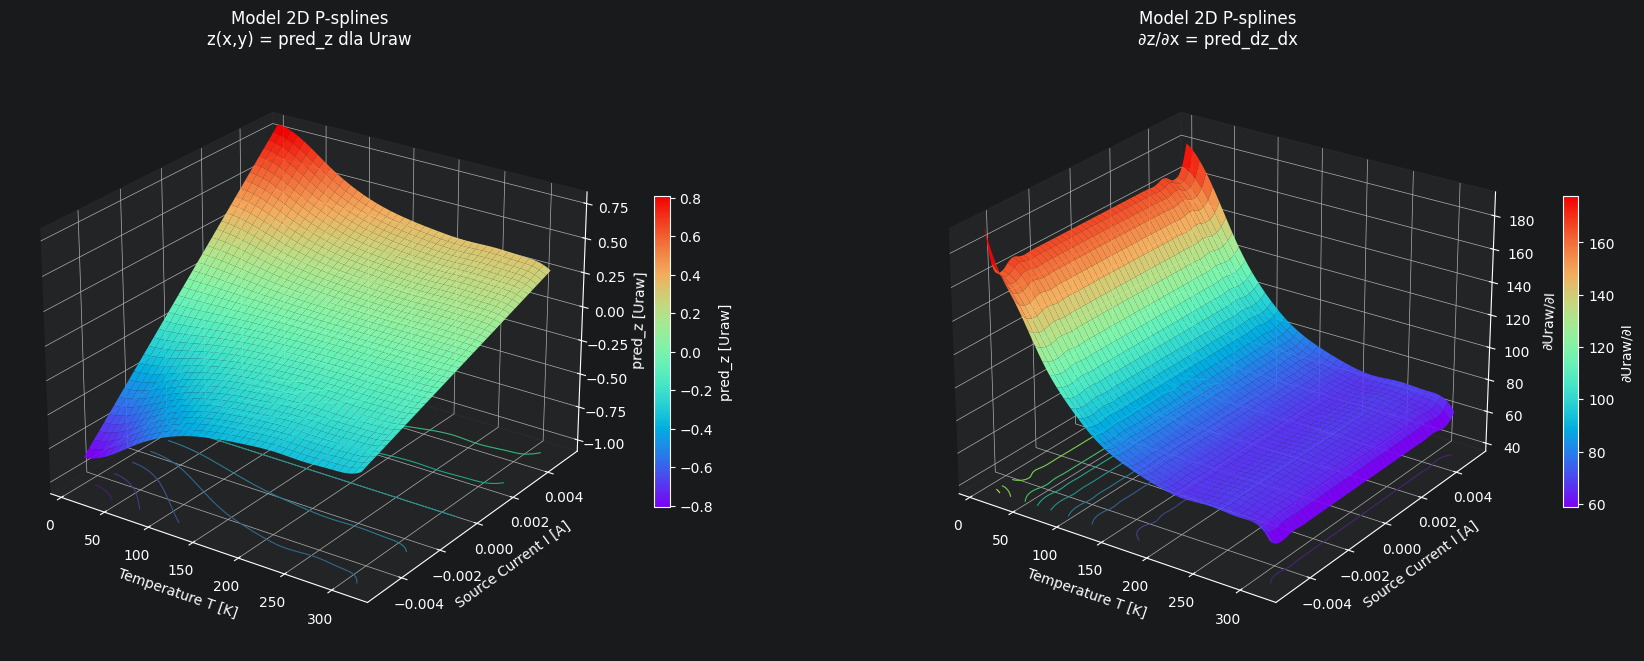

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def _pretty_axis_label(column_name: str) -> str:
    """Return a readable axis label for known physical columns."""
    if column_name == "T":
        return "Temperature T [K]"
    if column_name == "I":
        return "Source Current I [A]"
    return str(column_name)


def _surface_arrays_from_dataframe(
    df_surface: pd.DataFrame,
    *,
    horizontal_column: str,
    depth_column: str,
    value_column: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Build regular surface arrays from a long-form DataFrame.

    The input DataFrame is expected to contain columns:

    - `horizontal_column`,
    - `depth_column`,
    - `value_column`.

    Values are aggregated with `mean`, which makes the function robust to
    duplicate measurement points.
    """
    required_columns = [horizontal_column, depth_column, value_column]
    missing_columns = [col for col in required_columns if col not in df_surface.columns]
    if missing_columns:
        raise KeyError(f"Brakuje kolumn do wykresu powierzchni: {missing_columns}")

    plot_df = (
        df_surface.loc[:, required_columns]
        .dropna(subset=required_columns)
        .copy()
    )

    pivot = (
        plot_df.pivot_table(
            index=depth_column,
            columns=horizontal_column,
            values=value_column,
            aggfunc="mean",
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    if pivot.empty:
        raise ValueError(f"Brak danych do narysowania wykresu dla kolumny {value_column!r}.")

    horizontal_values = pivot.columns.to_numpy(dtype=float)
    depth_values = pivot.index.to_numpy(dtype=float)
    z_matrix = pivot.to_numpy(dtype=float)

    horizontal_mesh, depth_mesh = np.meshgrid(horizontal_values, depth_values)
    return horizontal_mesh, depth_mesh, z_matrix


def plot_prediction_surface_panel(
    fig: plt.Figure,
    ax: plt.Axes,
    df_surface: pd.DataFrame,
    *,
    horizontal_column: str,
    depth_column: str,
    value_column: str,
    title: str,
    zlabel: str,
) -> None:
    """Plot one 3D prediction surface with a projected contour map."""
    horizontal_mesh, depth_mesh, z_matrix = _surface_arrays_from_dataframe(
        df_surface,
        horizontal_column=horizontal_column,
        depth_column=depth_column,
        value_column=value_column,
    )

    z_masked = np.ma.masked_invalid(z_matrix)
    finite_values = z_matrix[np.isfinite(z_matrix)]

    if finite_values.size == 0:
        raise ValueError(f"Brak skończonych wartości dla kolumny {value_column!r}.")

    z_min = float(np.nanmin(finite_values))
    z_max = float(np.nanmax(finite_values))
    z_span = z_max - z_min if z_max > z_min else 1.0
    z_offset = z_min - 0.15 * z_span

    surface = ax.plot_surface(
        horizontal_mesh,
        depth_mesh,
        z_masked,
        cmap="rainbow",
        linewidth=0,
        antialiased=True,
        alpha=0.95,
    )

    try:
        ax.contour(
            horizontal_mesh,
            depth_mesh,
            z_masked,
            zdir="z",
            offset=z_offset,
            levels=12,
            cmap="viridis",
            linewidths=0.8,
        )
    except Exception as exc:
        print(f"Uwaga: pominięto kontury dla {value_column!r}: {exc}")

    colorbar = fig.colorbar(surface, ax=ax, shrink=0.52, pad=0.06)
    colorbar.set_label(zlabel)

    ax.set_title(title)
    ax.set_xlabel(_pretty_axis_label(horizontal_column))
    ax.set_ylabel(_pretty_axis_label(depth_column))
    ax.set_zlabel(zlabel)
    ax.set_zlim(z_offset, z_max)
    ax.view_init(elev=25, azim=-55)
    ax.grid(True)



if "grid_points" not in globals():
    raise RuntimeError("Brak DataFrame `grid_points`. Uruchom najpierw sekcję siatki predykcyjnej.")

required_final_plot_columns = [X_COLUMN, Y_COLUMN, "pred_z", "pred_dz_dx"]
missing_final_plot_columns = [
    col for col in required_final_plot_columns if col not in grid_points.columns
]
if missing_final_plot_columns:
    raise KeyError(f"Brakuje kolumn wymaganych do końcowych wykresów 3D: {missing_final_plot_columns}")

# Dla danych rzeczywistych domyślnie pokazujemy temperaturę T na osi poziomej,
# a prąd I na osi głębokości, zgodnie ze stylem notebooka preprocessingu.
# Wykres rysujemy z regularnej siatki modelowej `grid_points`, a nie z punktów
# pomiarowych `predicted_data`, aby ograniczyć artefakty krawędziowe.
horizontal_plot_column = Y_COLUMN
depth_plot_column = X_COLUMN
surface_plot_data = grid_points

print("Końcowe wykresy 3D są rysowane z regularnej siatki modelowej `grid_points`.")
print(f"Liczba punktów siatki: {len(surface_plot_data)}")
print(f"Kolumna osi poziomej: {horizontal_plot_column}")
print(f"Kolumna osi głębokości: {depth_plot_column}")

fig = plt.figure(figsize=(18, 6.5), constrained_layout=True)

ax_z = fig.add_subplot(1, 2, 1, projection="3d")
ax_dzdx = fig.add_subplot(1, 2, 2, projection="3d")

plot_prediction_surface_panel(
    fig,
    ax_z,
    surface_plot_data,
    horizontal_column=horizontal_plot_column,
    depth_column=depth_plot_column,
    value_column="pred_z",
    title=f"Model 2D P-splines\nz(x,y) = pred_z dla {target_column}",
    zlabel=f"pred_z [{target_column}]",
)

plot_prediction_surface_panel(
    fig,
    ax_dzdx,
    surface_plot_data,
    horizontal_column=horizontal_plot_column,
    depth_column=depth_plot_column,
    value_column="pred_dz_dx",
    title=f"Model 2D P-splines\n∂z/∂x = pred_dz_dx",
    zlabel=f"∂{target_column}/∂{X_COLUMN}",
)

plt.show()


## 19. Jedyny końcowy eksport CSV dla kolejnego etapu analizy

Na końcu notebooka zapisujemy **jeden** finalny plik CSV o nazwie zależnej od numeru próbki:

```text
real_data_sample{numer_próbki}_2D_predicted.csv
```

Dla domyślnego wejścia:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

plik wynikowy będzie miał nazwę:

```text
real_data_sample02_2D_predicted.csv
```

Ten eksport zastępuje wcześniejszy, bardziej ogólny wariant nazwy typu:

```text
A-B_VI_voltage_cleared_sample02_predicted.csv
```

Utrzymywanie obu plików jednocześnie nie jest potrzebne, ponieważ zawierałyby ten sam DataFrame `predicted_data`. Jeden finalny, jednoznacznie nazwany plik jest czytelniejszy dla kolejnego notebooka analizującego jakość i własności predykcji modelu.

Plik zawiera dane źródłowe, metadane konfiguracji modelu oraz komplet wielkości wyliczonych przez model.

W metadanych eksportowane są m.in. `model_n_basis_x`, `model_n_basis_y`, `model_n_coefficients`, `model_basis_selection_mode` oraz udziały współczynników. Jest to ważne, gdy `N_BASIS_X = None` i `N_BASIS_Y = None`, ponieważ liczba baz jest wtedy dobierana automatycznie na podstawie `TARGET_COEFFICIENT_FRACTION`.

Plik zawiera dane źródłowe oraz komplet wielkości wyliczonych przez model:

- `pred_z` — przewidziana wartość powierzchni,
- `pred_dz_dx` — pochodna pierwszego rzędu względem osi `x`,
- `pred_dz_dy` — pochodna pierwszego rzędu względem osi `y`,
- `pred_d2z_dx2` — druga pochodna względem osi `x`,
- `pred_d2z_dxdy` — pochodna mieszana,
- `pred_d2z_dy2` — druga pochodna względem osi `y`.

Jeżeli plik wejściowy zawiera dodatkowe kolumny, zostają one zachowane, ponieważ zapisujemy DataFrame `predicted_data` zbudowany w sekcji budowy predykcji.


In [21]:
import re


def extract_sample_label_from_path(path: Path) -> str:
    """Extract a sample label such as '02' from a filename containing 'sample02'.

    The function is intentionally conservative: it searches the stem of the
    input file path and raises a readable error if no sample number is found.
    """
    match = re.search(r"sample(\d+)", path.stem, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(
            "Nie udało się wyznaczyć numeru próbki z nazwy pliku wejściowego: "
            f"{path.name!r}. Oczekiwany fragment nazwy to np. 'sample02'."
        )
    return match.group(1)


if "predicted_data" not in globals():
    raise RuntimeError("Brak DataFrame `predicted_data`. Uruchom najpierw sekcję eksportu predykcji.")

required_model_output_columns = [
    "pred_z",
    "pred_dz_dx",
    "pred_dz_dy",
    "pred_d2z_dx2",
    "pred_d2z_dxdy",
    "pred_d2z_dy2",
]

missing_model_output_columns = [
    column for column in required_model_output_columns if column not in predicted_data.columns
]

if missing_model_output_columns:
    raise AssertionError(
        "Brakuje kolumn predykcyjnych wymaganych w eksporcie końcowym: "
        f"{missing_model_output_columns}"
    )

sample_label = extract_sample_label_from_path(data_path)
default_output_filename = f"real_data_sample{sample_label}_2D_predicted.csv"

if FINAL_OUTPUT_PREDICTIONS_FILE is None:
    real_output_path = data_path.parent / default_output_filename
else:
    real_output_path = Path(FINAL_OUTPUT_PREDICTIONS_FILE)
    if not real_output_path.is_absolute():
        real_output_path = data_path.parent / real_output_path

predicted_data.to_csv(real_output_path, index=False)

print(f"Zapisano jedyny końcowy plik predykcji: {real_output_path}")
print(f"Liczba wierszy: {len(predicted_data)}")
print(f"Liczba kolumn: {len(predicted_data.columns)}")
print("Kolumny predykcyjne zapisane w pliku:")
for column in required_model_output_columns:
    print(f"- {column}")


Zapisano jedyny końcowy plik predykcji: D:\PycharmProjects\2D_p-splines-fiiting\data\processed\real_data_sample02_2D_predicted.csv
Liczba wierszy: 6261
Liczba kolumn: 21
Kolumny predykcyjne zapisane w pliku:
- pred_z
- pred_dz_dx
- pred_dz_dy
- pred_d2z_dx2
- pred_d2z_dxdy
- pred_d2z_dy2
